# Analyze emission experimets

- Daniel Armas Ramírez
- Ian Josué López Sánchez

2026-A071

## Preparación de dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "model": [
        "qwen-8b-qlora",
        "gemma-12b-qlora",
        "mistral-mistral-7b-qlora",
        "gpt-oss-20b-unsloth",
        "gemma-12b-quant",
        "qwen-14b-sdpa-lora",
        "qwen-14b-fa-lora",
        "llama-8b-lora",
    ],
    "bertscore_precision_mean": [
        0.528534, 0.507841, 0.657495,
        0.520516, 0.506315, 0.539134, 0.539553, 0.760818,
    ],
    "bertscore_recall_mean": [
        0.685004, 0.672949, 0.717226,
        0.675696, 0.673331, 0.717064, 0.717233, 0.768971,
    ],
    "bertscore_f1_mean": [
        0.595142, 0.577209, 0.683873,
        0.586416, 0.576377, 0.612846, 0.613167, 0.762902,
    ],
}

df_bert = pd.DataFrame(data)
df_bert.head()

,model,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean
0,qwen-8b-qlora,0.528534,0.685004,0.595142
1,gemma-12b-qlora,0.507841,0.672949,0.577209
2,mistral-mistral-7b-qlora,0.657495,0.717226,0.683873
3,gpt-oss-20b-unsloth,0.520516,0.675696,0.586416
4,gemma-12b-quant,0.506315,0.673331,0.576377


In [3]:
df = pd.read_csv("experiments_emissions.csv")
df_sci_scores = pd.read_csv("sci_scores.csv")

df = df.merge(df_sci_scores, on="project_name", how="left")
df = df.merge(df_bert, on="model", how="left")
df.head()

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue,model,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean
0,2026-05-05T17:51:00,bio-gpt-oss-20b-quant,75f6dad4-434f-46ff-8526-fcd24b30e7e3,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,4212.674029,0.122389,0.000029,4.278336,228.418768,11.313035,...,7.926898,13.227876,Y,1.0,0.0,gpt-oss-20b-unsloth,189.509124,0.520516,0.675696,0.586416
1,2026-04-29T18:47:42,bio-gemma-3-12b-qlora,cb886d24-0ff7-4cce-a0b2-e64e9cc8520e,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,6834.935725,0.364423,0.000053,9.517877,359.407776,10.002933,...,9.478131,35.717012,N,1.0,0.0,gemma-12b-qlora,356.661393,0.507841,0.672949,0.577209
2,2026-05-01T23:13:50,bio-gemma-3-12b-quant,a7675576-ff88-4c97-8242-3bc81df2a7d8,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,15007.153242,0.527249,0.000035,163.507432,171.492048,10.005341,...,8.397770,18.187650,N,1.0,0.0,gemma-12b-quant,406.104269,0.506315,0.673331,0.576377
3,2026-05-12T09:01:35,bio-ministral-3-14b-qlora,3814d7a8-c933-4635-88c1-3d4047faf850,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,13903.904257,0.335942,0.000024,42.500000,184.149510,10.010094,...,7.221977,15.627171,N,1.0,0.0,ministral-ministral-14b-qlora,264.993742,NaN,NaN,NaN
4,2026-05-12T03:26:26,bio-ministral-3-14b-lora,48164eff-1c5d-4a4c-b00d-c26664d68168,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,6420.491519,0.148022,0.000023,42.500000,173.415093,10.001563,...,7.224093,15.648005,N,1.0,0.0,ministral-ministral-14b-lora,117.214505,NaN,NaN,NaN


In [4]:
df_temp = df.copy()
model_names = df_temp['project_name'].str.split('-')
sizes = []

for model in model_names:
    for word in model:
        if word.endswith('b'):
            sz = word
            break
    sz = sz.replace('b', '')
    sizes.append(int(sz))

df['size'] = sizes
df.head()

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,ram_used_gb,on_cloud,pue,wue,model,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size
0,2026-05-05T17:51:00,bio-gpt-oss-20b-quant,75f6dad4-434f-46ff-8526-fcd24b30e7e3,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,4212.674029,0.122389,0.000029,4.278336,228.418768,11.313035,...,13.227876,Y,1.0,0.0,gpt-oss-20b-unsloth,189.509124,0.520516,0.675696,0.586416,20
1,2026-04-29T18:47:42,bio-gemma-3-12b-qlora,cb886d24-0ff7-4cce-a0b2-e64e9cc8520e,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,6834.935725,0.364423,0.000053,9.517877,359.407776,10.002933,...,35.717012,N,1.0,0.0,gemma-12b-qlora,356.661393,0.507841,0.672949,0.577209,12
2,2026-05-01T23:13:50,bio-gemma-3-12b-quant,a7675576-ff88-4c97-8242-3bc81df2a7d8,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,15007.153242,0.527249,0.000035,163.507432,171.492048,10.005341,...,18.187650,N,1.0,0.0,gemma-12b-quant,406.104269,0.506315,0.673331,0.576377,12
3,2026-05-12T09:01:35,bio-ministral-3-14b-qlora,3814d7a8-c933-4635-88c1-3d4047faf850,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,13903.904257,0.335942,0.000024,42.500000,184.149510,10.010094,...,15.627171,N,1.0,0.0,ministral-ministral-14b-qlora,264.993742,NaN,NaN,NaN,14
4,2026-05-12T03:26:26,bio-ministral-3-14b-lora,48164eff-1c5d-4a4c-b00d-c26664d68168,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,6420.491519,0.148022,0.000023,42.500000,173.415093,10.001563,...,15.648005,N,1.0,0.0,ministral-ministral-14b-lora,117.214505,NaN,NaN,NaN,14


In [72]:
cols = ['project_name', 'model', 'duration', 'cpu_power', 'gpu_power', 'ram_power', 'cpu_energy', 'gpu_energy', 'ram_energy', 'energy_consumed', 'cpu_count', 'cpu_model', 'gpu_count', 'gpu_model', 'ram_total_size', 'cpu_utilization_percent', 'gpu_utilization_percent', 'ram_utilization_percent', 'ram_used_gb', 'sci_score', 'bertscore_precision_mean', 'bertscore_recall_mean', 'bertscore_f1_mean', 'size', 'region']
df_emissions = df[cols]
df_emissions.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,...,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size,region
0,bio-gpt-oss-20b-quant,gpt-oss-20b-unsloth,4212.674029,4.278336,228.418768,11.313035,0.004970,0.266620,0.013035,0.284625,...,9.241657,87.619614,7.926898,13.227876,189.509124,0.520516,0.675696,0.586416,20,Iowa
1,bio-gemma-3-12b-qlora,gemma-12b-qlora,6834.935725,9.517877,359.407776,10.002933,0.017995,0.681589,0.018853,0.718436,...,10.298856,70.963992,9.478131,35.717012,356.661393,0.507841,0.672949,0.577209,12,mexico city
2,bio-gemma-3-12b-quant,gemma-12b-quant,15007.153242,163.507432,171.492048,10.005341,0.675080,0.712241,0.041017,1.428338,...,3.664639,50.161314,8.397770,18.187650,406.104269,0.506315,0.673331,0.576377,12,virginia
3,bio-ministral-3-14b-qlora,ministral-ministral-14b-qlora,13903.904257,42.500000,184.149510,10.010094,0.163610,0.708173,0.038298,0.910081,...,3.644985,57.492105,7.221977,15.627171,264.993742,NaN,NaN,NaN,14,virginia
4,bio-ministral-3-14b-lora,ministral-ministral-14b-lora,6420.491519,42.500000,173.415093,10.001563,0.075534,0.307812,0.017651,0.400998,...,3.672827,44.188399,7.224093,15.648005,117.214505,NaN,NaN,NaN,14,virginia


In [31]:
plt.style.use('seaborn-v0_8')

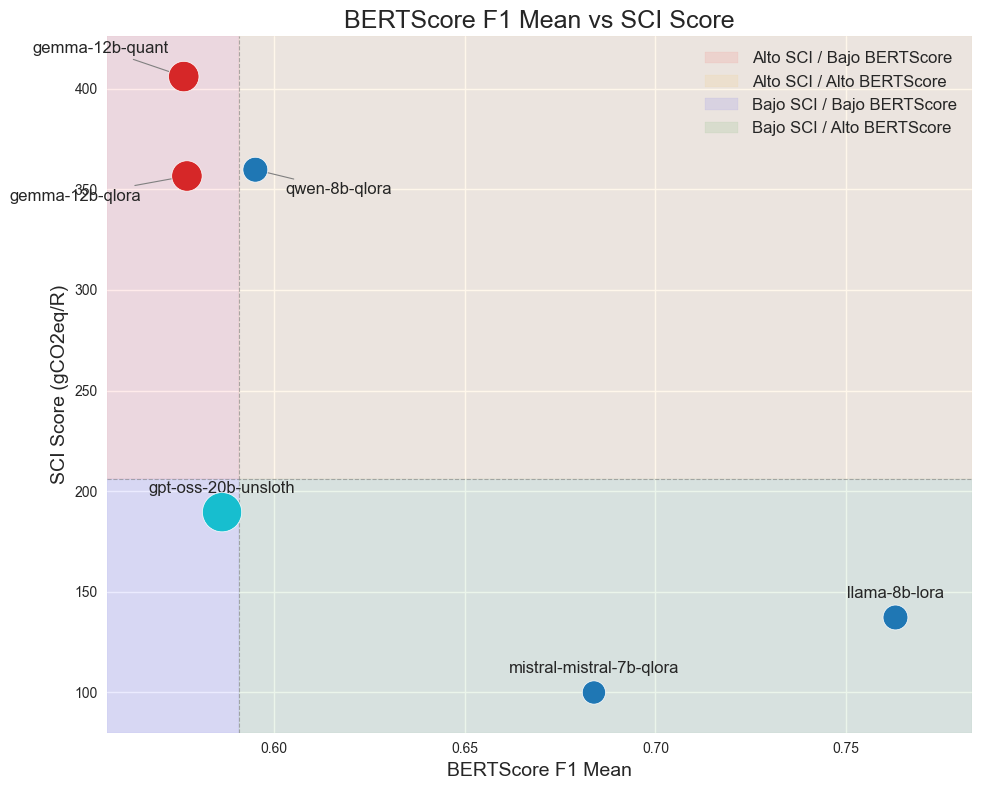

In [78]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 8)

x = df_emissions['bertscore_f1_mean']
y = df_emissions['sci_score']

x_mid = x.median()
y_mid = y.median()

ax.axvline(x=x_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=y_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

x_min, x_max = x.min() - 0.02, x.max() + 0.02
y_min, y_max = y.min() - 20, y.max() + 20

ax.axvspan(x_min, x_mid, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='red',    label='Alto SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='orange', label='Alto SCI / Alto BERTScore')
ax.axvspan(x_min, x_mid, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='blue',   label='Bajo SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='green',  label='Bajo SCI / Alto BERTScore')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

sc = ax.scatter(x, y, s=df_emissions['size'] * 40, c=df_emissions['size'], cmap='tab10', zorder=5, edgecolors='white', linewidth=0.5)

label_offsets = {
    'gemma-12b-quant': (-60, 15),
    'gemma-12b-qlora': (-80, -20),
    'qwen-8b-qlora':   (60, -20),
}

for i, row in df_emissions.iterrows():
    name = row['model']
    ox, oy = label_offsets.get(name, (0, 12))
    use_arrow = name in label_offsets
    ax.annotate(
        name,
        (row['bertscore_f1_mean'], row['sci_score']),
        fontsize=12, ha='center', va='bottom',
        xytext=(ox, oy), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8) if use_arrow else None,
    )

ax.set_xlabel('BERTScore F1 Mean', fontsize=14)
ax.set_ylabel('SCI Score (gCO2eq/R)', fontsize=14)
ax.set_title('BERTScore F1 Mean vs SCI Score', fontsize=18)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
fig.savefig('../../TT2-pre/bertscore_sci_score.png', transparent=True, bbox_inches='tight')

In [85]:
df_temp_bert = df_emissions[df_emissions['bertscore_f1_mean'].notna()]
df_temp_bert.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,...,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size,region
0,bio-gpt-oss-20b-quant,gpt-oss-20b-unsloth,4212.674029,4.278336,228.418768,11.313035,0.004970,0.266620,0.013035,0.284625,...,9.241657,87.619614,7.926898,13.227876,189.509124,0.520516,0.675696,0.586416,20,Iowa
1,bio-gemma-3-12b-qlora,gemma-12b-qlora,6834.935725,9.517877,359.407776,10.002933,0.017995,0.681589,0.018853,0.718436,...,10.298856,70.963992,9.478131,35.717012,356.661393,0.507841,0.672949,0.577209,12,mexico city
2,bio-gemma-3-12b-quant,gemma-12b-quant,15007.153242,163.507432,171.492048,10.005341,0.675080,0.712241,0.041017,1.428338,...,3.664639,50.161314,8.397770,18.187650,406.104269,0.506315,0.673331,0.576377,12,virginia
8,bio-qwen-3-8b-qlora,qwen-8b-qlora,10944.011386,4.984529,160.416308,10.000916,0.015016,0.485828,0.029903,0.530747,...,9.396380,39.540323,8.577392,14.293998,359.791245,0.528534,0.685004,0.595142,8,Iowa
9,bio-mistral-7b,mistral-mistral-7b-qlora,3552.214359,42.500000,307.712386,10.019729,0.041753,0.302282,0.009694,0.353728,...,3.771961,87.496756,5.045811,10.860997,99.860064,0.657495,0.717226,0.683873,7,virginia


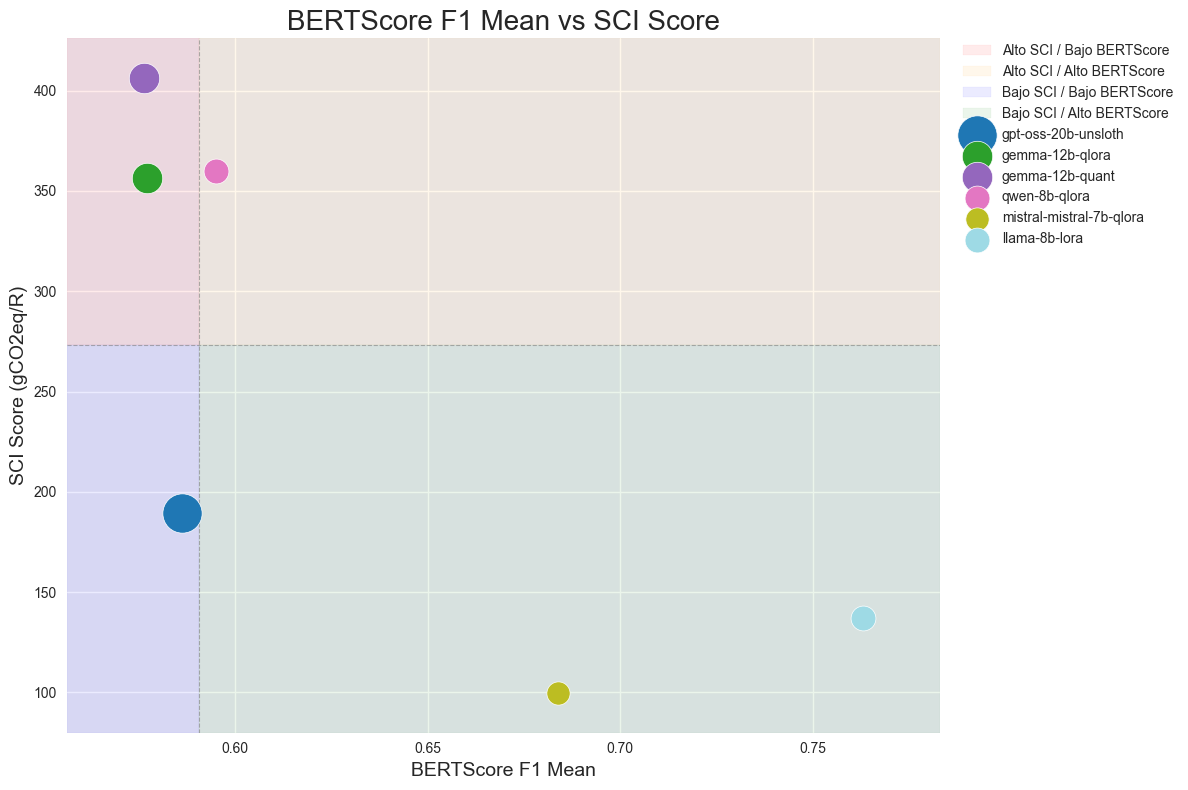

In [86]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 8)


x = df_temp_bert['bertscore_f1_mean']
y = df_temp_bert['sci_score']

x_mid = x.median()
y_mid = y.median()

ax.axvline(x=x_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=y_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

x_min, x_max = x.min() - 0.02, x.max() + 0.02
y_min, y_max = y.min() - 20, y.max() + 20

ax.axvspan(x_min, x_mid, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='red',    label='Alto SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='orange', label='Alto SCI / Alto BERTScore')
ax.axvspan(x_min, x_mid, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='blue',   label='Bajo SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='green',  label='Bajo SCI / Alto BERTScore')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

colors = plt.cm.tab20(np.linspace(0, 1, len(df_temp_bert)))

label_offsets = {
    'gemma-12b-quant': (-60, 15),
    'gemma-12b-qlora': (-80, -20),
    'qwen-8b-qlora':   (60, -20),
}

for idx, (i, row) in enumerate(df_temp_bert.iterrows()):
    name = row['model']
    c = colors[idx]
    ax.scatter(row['bertscore_f1_mean'], row['sci_score'],
               s=row['size'] * 40, color=c, zorder=5,
               edgecolors='white', linewidth=0.5, label=name)
    ox, oy = label_offsets.get(name, (0, 12))
    use_arrow = name in label_offsets

ax.set_xlabel('BERTScore F1 Mean', fontsize=14)
ax.set_ylabel('SCI Score (gCO2eq/R)', fontsize=14)
ax.set_title('BERTScore F1 Mean vs SCI Score', fontsize=20)

ax.legend(
    bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10,
    borderaxespad=0, framealpha=0.9,
)

plt.tight_layout()
plt.show()
fig.savefig('../../TT2-pre/bertscore_sci_score.png', transparent=True, bbox_inches='tight')

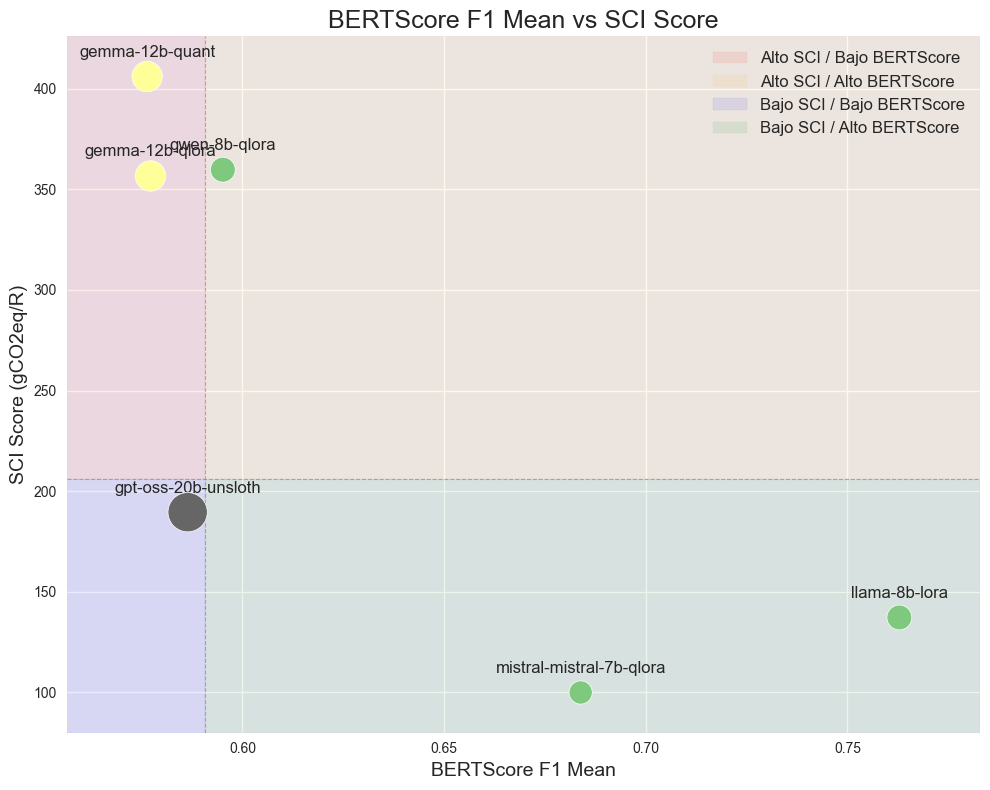

In [77]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 8)

x = df_emissions['bertscore_f1_mean']
y = df_emissions['sci_score']

x_mid = x.median()
y_mid = y.median()

ax.axvline(x=x_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(y=y_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

x_min, x_max = x.min() - 0.02, x.max() + 0.02
y_min, y_max = y.min() - 20, y.max() + 20

ax.axvspan(x_min, x_mid, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='red',    label='Alto SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=(y_mid - y_min) / (y_max - y_min), ymax=1, alpha=0.08, color='orange', label='Alto SCI / Alto BERTScore')
ax.axvspan(x_min, x_mid, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='blue',   label='Bajo SCI / Bajo BERTScore')
ax.axvspan(x_mid, x_max, ymin=0, ymax=(y_mid - y_min) / (y_max - y_min), alpha=0.08, color='green',  label='Bajo SCI / Alto BERTScore')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

sc = ax.scatter(x, y, s=df_emissions['size'] * 40, c=df_emissions['size'], cmap='Accent', zorder=5, edgecolors='white', linewidth=0.5)
for i, row in df_emissions.iterrows():
    ax.annotate(row['model'], (row['bertscore_f1_mean'], row['sci_score']),
                fontsize=12, ha='center', va='bottom', xytext=(0, 12),
                textcoords='offset points')

ax.set_xlabel('BERTScore F1 Mean', fontsize=14)
ax.set_ylabel('SCI Score (gCO2eq/R)', fontsize=14)
ax.set_title('BERTScore F1 Mean vs SCI Score', fontsize=18)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
fig.savefig('../../TT2-pre/bertscore_sci_score.png', transparent=True, bbox_inches='tight')

In [9]:
df_emissions.describe()

,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,gpu_count,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,6.000000,6.000000,6.000000,12.000000
mean,8217.872648,47.786966,205.216396,10.113775,0.116857,0.436565,0.022620,0.576042,32.166667,1.083333,213.242920,6.163421,55.365362,7.547267,16.262819,235.566206,0.580253,0.698863,0.630320,11.583333
std,3796.346890,58.015201,67.231354,0.377710,0.188727,0.178160,0.010231,0.319575,31.397259,0.288675,56.726212,3.042786,17.788771,1.217772,6.441487,112.263349,0.105379,0.038222,0.076605,3.895413
min,3552.214359,4.278336,125.439936,10.000000,0.004970,0.238797,0.009694,0.284625,12.000000,1.000000,167.042805,3.644985,34.375015,5.045811,10.860997,99.860064,0.506315,0.672949,0.576377,7.000000
25%,5768.571769,5.121660,168.723113,10.001355,0.016172,0.299176,0.015847,0.389180,12.000000,1.000000,167.042809,3.673409,43.251808,6.850120,14.027468,136.564424,0.511010,0.673922,0.579511,8.000000
50%,6758.154622,42.500000,178.782301,10.003128,0.056333,0.371595,0.018616,0.474666,30.000000,1.000000,216.258427,3.802184,50.686791,7.223035,15.000532,206.189817,0.524525,0.680350,0.590779,12.000000
75%,11132.028570,42.500000,225.449555,10.007668,0.099831,0.547190,0.030330,0.592529,30.000000,1.000000,216.258428,9.424579,60.860077,8.442675,15.632380,357.443856,0.625255,0.709171,0.661690,14.000000
max,15007.153242,168.753491,359.407776,11.313035,0.675080,0.712241,0.041017,1.428338,128.000000,2.000000,376.934826,10.298856,87.619614,9.478131,35.717012,406.104269,0.760818,0.768971,0.762902,20.000000


> Experiments with most power consumption

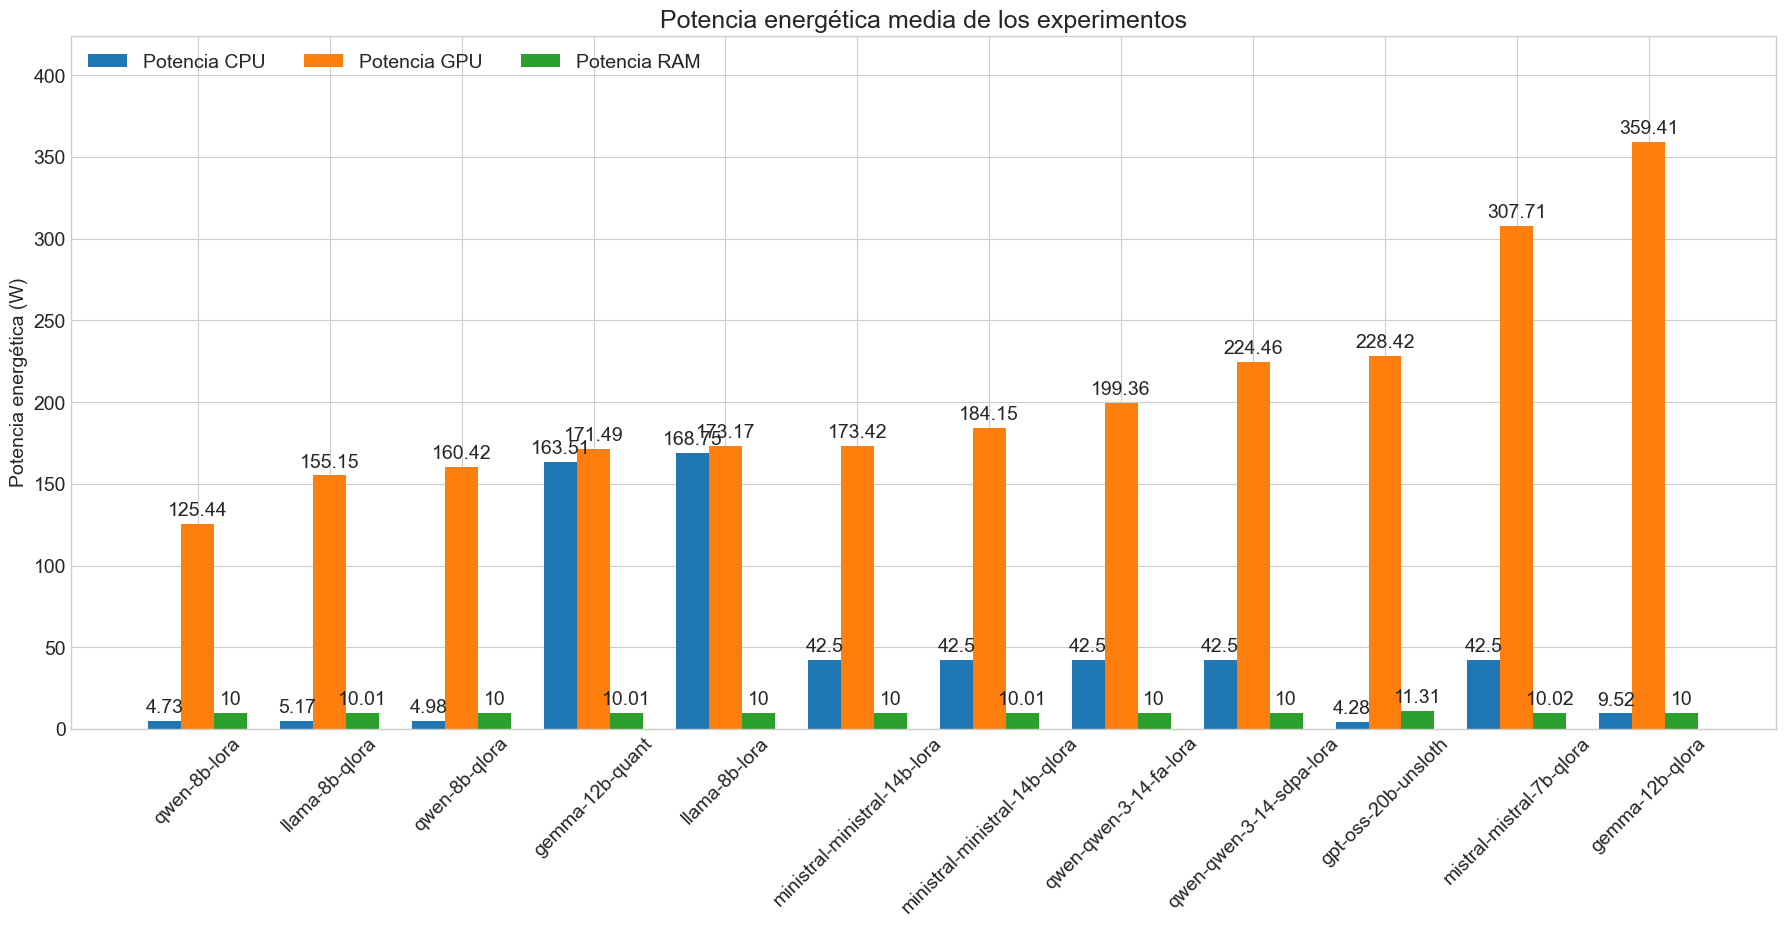

In [28]:
# spanish
df_temp
df_temp = df_emissions.sort_values(by='gpu_power', ascending=True).reset_index(drop=True)
models = (df_temp['model'].unique())
df_power_data = {
    'Potencia CPU': df_temp['cpu_power'],
    'Potencia GPU': df_temp['gpu_power'],
    'Potencia RAM': df_temp['ram_power']
}
x= np.arange(len(models))
width = 0.25
multiplier = 0

fig, ax = plt.subplots()

max_value = 0
for attribute, measurement in df_power_data.items():
    offset = width * multiplier
    measurement = np.round(measurement, 2)
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    # avoid label overlap
    ax.bar_label(rects, padding=3, fontsize=14)
    max_value = max(max_value, measurement.max())
    multiplier += 1

# for i in range(len(models) - 1):
#     ax.axvline(x=i + 0.5 + width * 1.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
# change font size
ax.tick_params(axis='both', which='major', labelsize=14)

ax.figure.set_size_inches(22, 9)
ax.set_ylabel('Potencia energética (W)', fontsize=14)
ax.set_title('Potencia energética media de los experimentos', fontsize=18)
ax.set_xticks(x + width, models)
ax.legend(loc='upper left', ncols=3, fontsize=14)
ax.set_ylim(0, max_value * 1.18)
ax.xaxis.set_tick_params(rotation=45)
ax.set_facecolor('white')
plt.show()
fig.savefig('../../TT2-pre/all_power_consumption.png', transparent=True, bbox_inches='tight')

In [53]:
df_power_data["Potencia GPU"].mean()

np.float64(205.21639618233462)

> 3 de los modelos QLoRA tienen la mayor potencia energética en GPU, mientras que gemma 12b quant y llama 8b lora tienen la mayor potencia energética en CPU, esto no significa que su consumo energético será mayor, como se verá a continuación.

> La potencia de memoria RAM es similar en todos los experimentos, mostrando su comportamiento inactivo o idle durante el fine-tuning, aunque no esté siendo utilizada, se encuentra encendida y consumiendo energía.

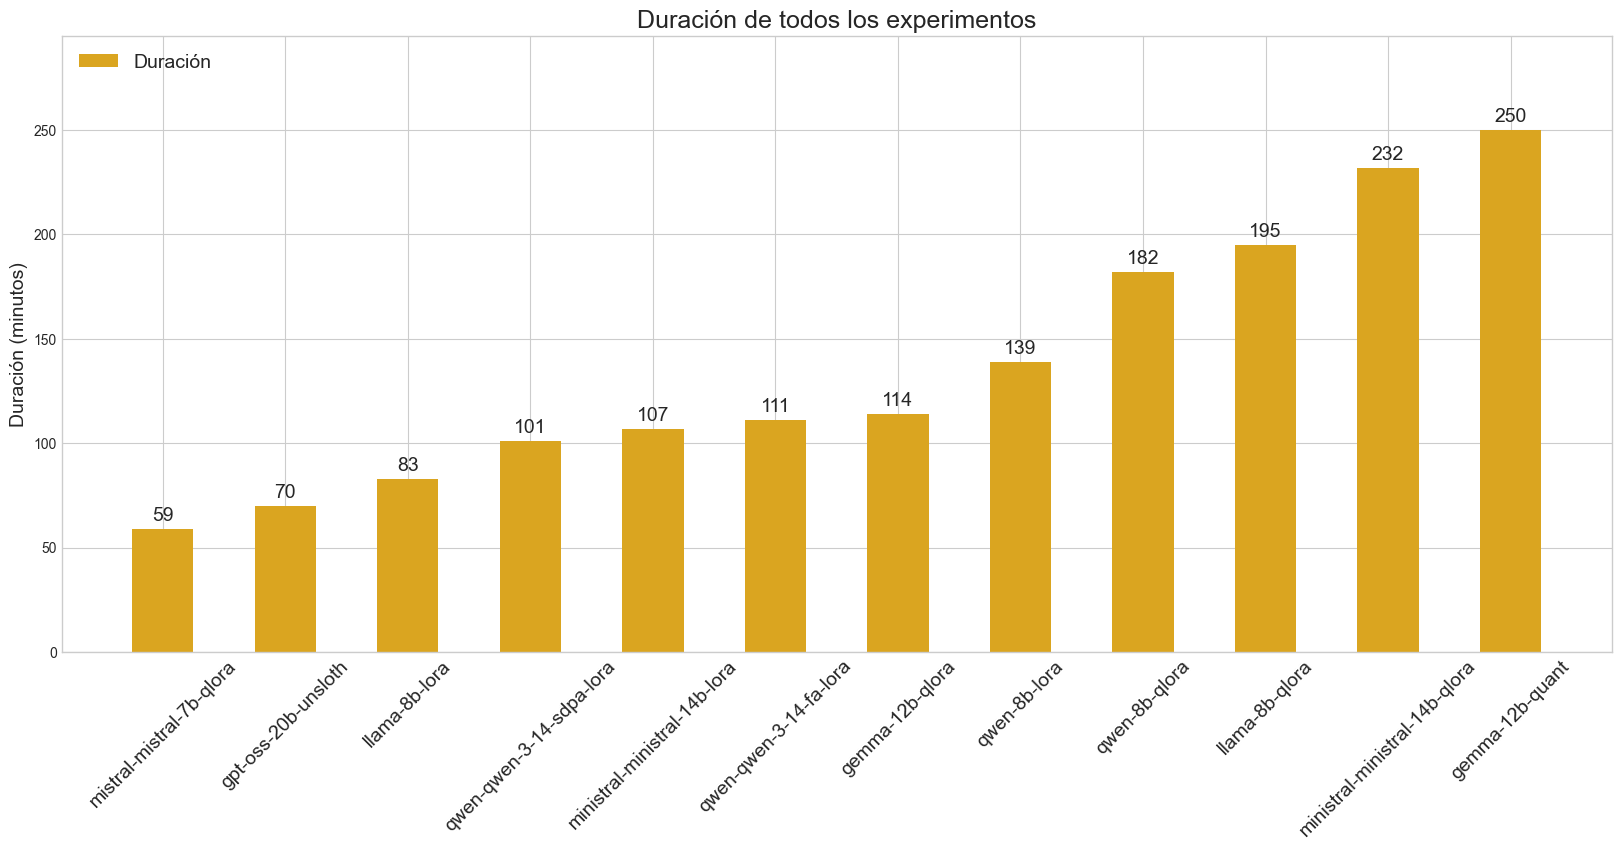

In [57]:
df_temp3 = df_emissions.sort_values(by='duration', ascending=True).reset_index(drop=True)
df_temp3['duration_minutes'] = df_temp3['duration'] / 60
models = (df_temp3['model'].unique())
models = df_temp3['model'].unique()
x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots()

measurement = np.round(df_temp3['duration_minutes'])
rects = ax.bar(x, measurement, width, label='Duración', color='goldenrod')
ax.bar_label(rects, padding=3, fontsize=14)

ax.figure.set_size_inches(20, 8)
ax.set_ylabel('Duración (minutos)', fontsize=14)
ax.set_title('Duración de todos los experimentos', fontsize=18)
ax.set_xticks(x, models, fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.set_ylim(0, measurement.max() * 1.18)
ax.xaxis.set_tick_params(rotation=45)
plt.show()
fig.savefig('../../TT2-pre/all_duration.png', transparent=True, bbox_inches='tight')

Otra variable importante es la duración del experimento, una variable que afectará el consumo energético, gemma 12b quant fue el experimento con mayor duración, sin embargo no tuvo la mayor potencia energética de GPU, pero sí en CPU, se puede notar que los 3 experimentos más tardados son con la configuración QLoRA, mientras que gpt-oss y mistral 7b son los más rápidos y utilizan cuantización, LoRA es una técnica eficiente en el tiempo de ejecución.

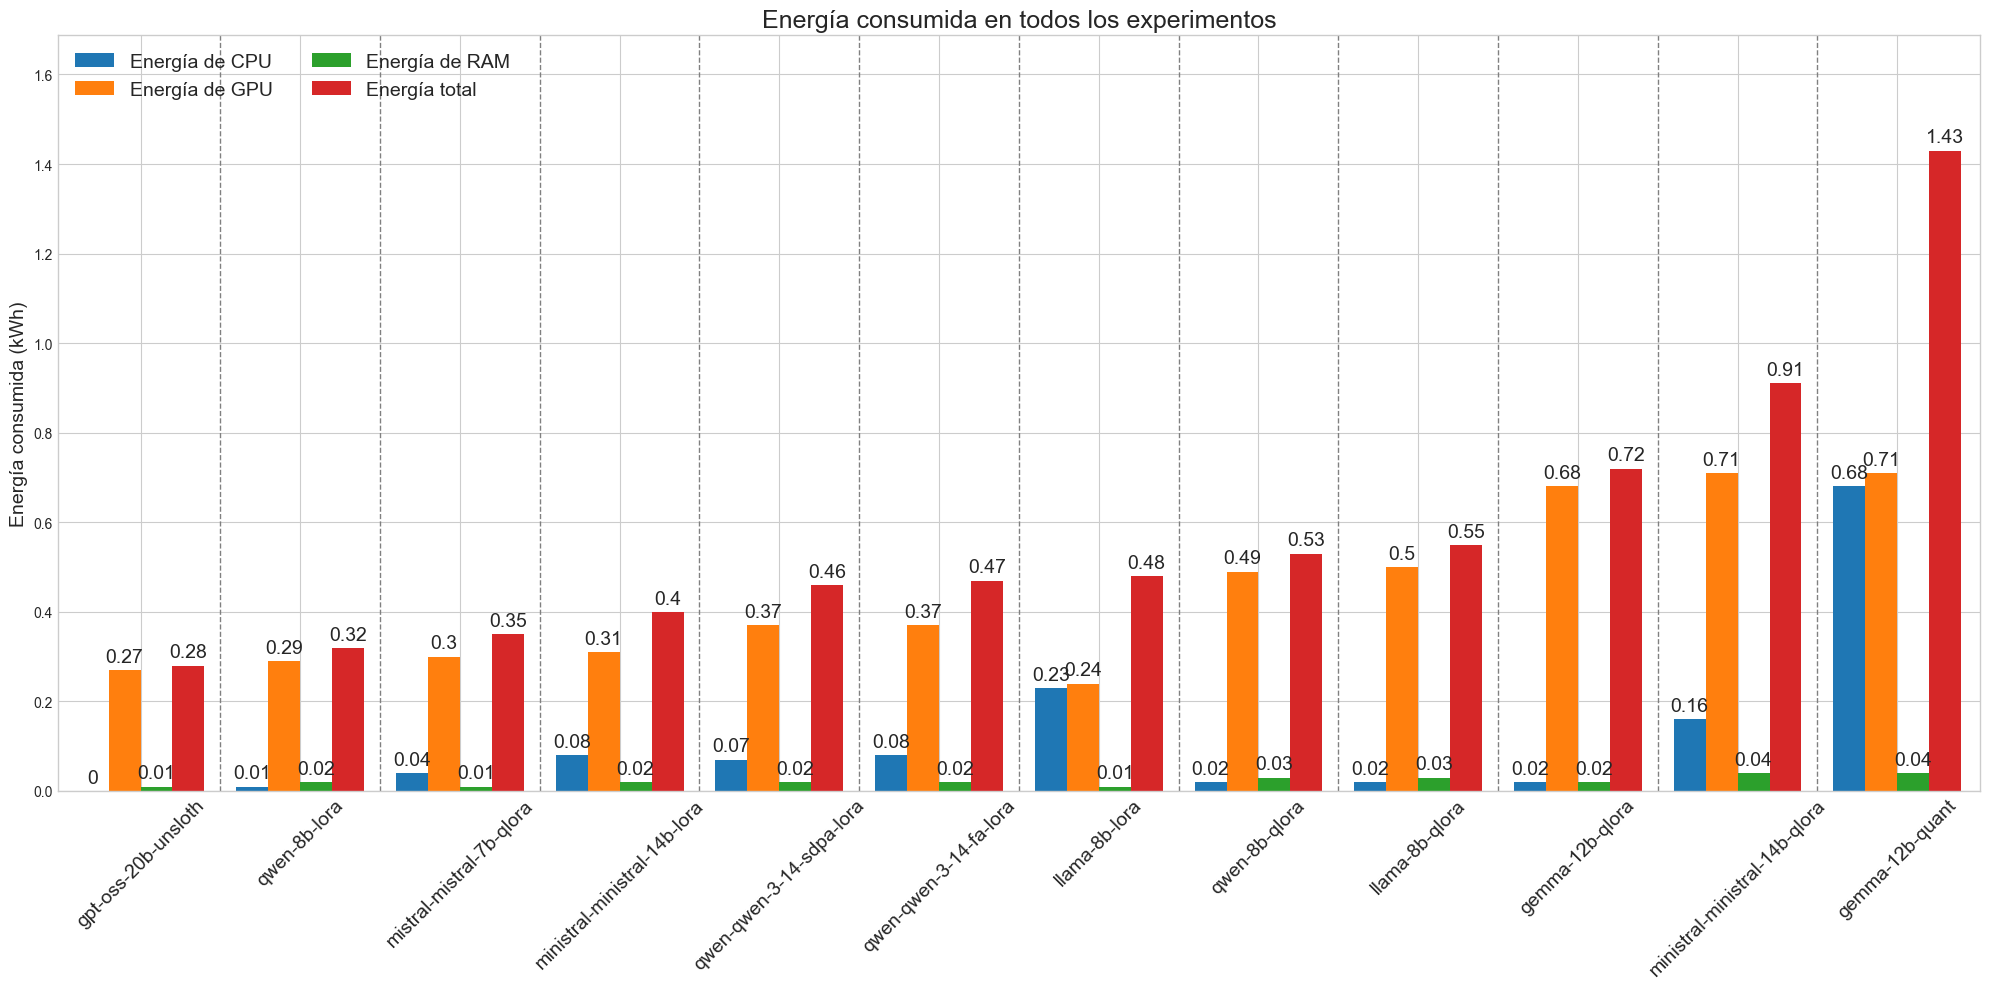

In [48]:
df_temp2 = df_emissions.sort_values(by='energy_consumed', ascending=True).reset_index(drop=True)
models = (df_temp2['model'].unique())
energy_data = {
    'Energía de CPU': df_temp2['cpu_energy'],
    'Energía de GPU': df_temp2['gpu_energy'],
    'Energía de RAM': df_temp2['ram_energy'],
    'Energía total': df_temp2['energy_consumed']
}
x= np.arange(len(models))
width = 0.20
multiplier = 0

fig, ax = plt.subplots()

max_value = 0
for attribute, measurement in energy_data.items():
    offset = width * multiplier
    measurement = np.round(measurement, 2)
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fontsize=14)
    max_value = max(max_value, measurement.max())
    multiplier += 1


for i in range(len(models) - 1):
    ax.axvline(x=i + 0.5 + width * 1.5, color='gray', linestyle='--', linewidth=1, alpha=1)

ax.figure.set_size_inches(20, 10)
ax.set_ylabel('Energía consumida (kWh)', fontsize=14)
ax.set_title('Energía consumida en todos los experimentos', fontsize=18)
ax.set_xticks(x + width * 1.5, models, fontsize=14)
ax.legend(loc='upper left', ncols=2, fontsize=14)
ax.set_ylim(0, max_value * 1.18)
ax.margins(x=0.01)
ax.xaxis.set_tick_params(rotation=45)
plt.tight_layout()
plt.show()
fig.savefig('../../TT2-pre/all_energy_consumption.png', transparent=True, bbox_inches='tight')

> Los modelos con cuantización y LoRA (QLoRA) tienen un consumo más alto de energía, se pueden notar a la derecha del gráfico, los dos modelos QLoRA que no aparecen son gpt-oss y mistral 7b, que están cuantizados a NF4, gemma-12b-quant usa cuantización de entero de 8 bits, aunque QLoRA permite reducir el modelo en VRAM no representa una mejora para fine-tuning en consumo energético.

> Gemma 12b quant tiene uno de los mayores consumos de energía en CPU y también una alta potencia energética de CPU, para la GPU no es tan alta la potencia, sin embargo su tiempo de ejecución fue más largo.

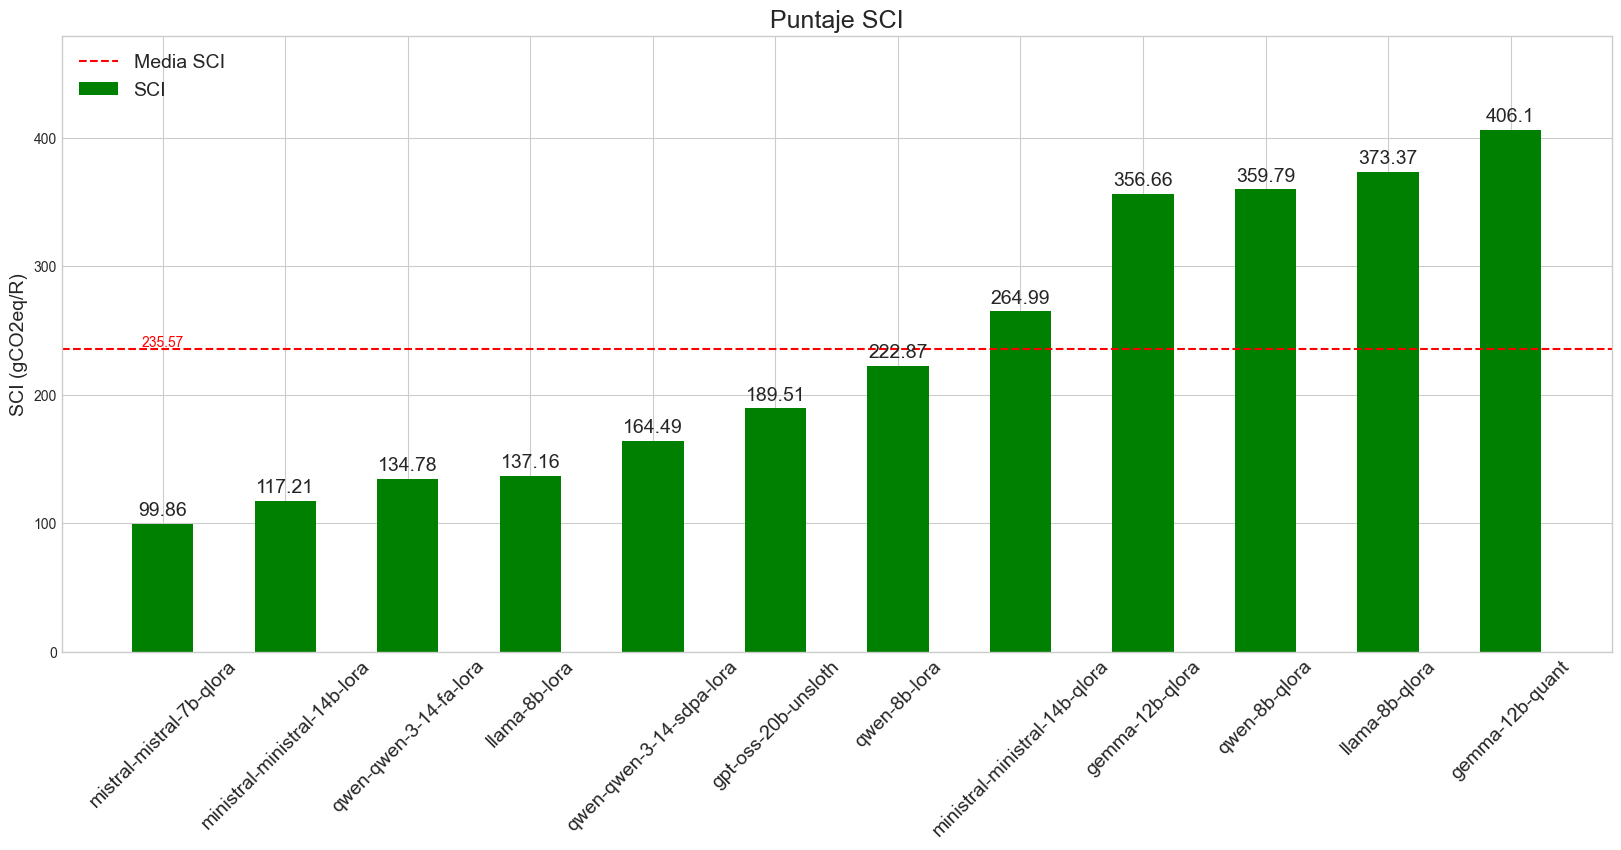

In [60]:
temp4 = df_emissions.sort_values(by='sci_score', ascending=True).reset_index(drop=True)
models = (temp4['model'].unique())
x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots()

measurement = np.round(temp4['sci_score'], 2)
rects = ax.bar(x, measurement, width, label='SCI', color='g')
ax.bar_label(rects, padding=3, fontsize=14)

ax.axhline(y=temp4['sci_score'].mean(), color='r', linestyle='--', label='Media SCI')
ax.text(0, temp4['sci_score'].mean(), f'{temp4["sci_score"].mean():.2f}', ha='center', va='bottom', color='r')

ax.figure.set_size_inches(20, 8)
ax.set_ylabel('SCI (gCO2eq/R)', fontsize=14)
ax.set_title('Puntaje SCI', fontsize=18)
ax.set_xticks(x, models, fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.set_ylim(0, measurement.max() * 1.18)
ax.xaxis.set_tick_params(rotation=45)
plt.show()
fig.savefig('../../TT2-pre/all_sci_score.png', transparent=True, bbox_inches='tight')

In [27]:
def plot_vars_analysis(df_temp, var_name, width, multiplier, max_value, save_path, title, y_label):
    models = (df_temp['model'].unique())
    if var_name != 'energy':
        temp_data = {
            f'{var_name.capitalize()} CPU': df_temp[f'cpu_{var_name}'],
            f'{var_name.capitalize()} GPU': df_temp[f'gpu_{var_name}'],
            f'{var_name.capitalize()} RAM': df_temp[f'ram_{var_name}']
        }
    else:
        temp_data = {
            f'{var_name.capitalize()} CPU': df_temp[f'cpu_{var_name}'],
            f'{var_name.capitalize()} GPU': df_temp[f'gpu_{var_name}'],
            f'{var_name.capitalize()} RAM': df_temp[f'ram_{var_name}'],
            f'{var_name.capitalize()} total': df_temp[f'{var_name}_consumed']
        }
    x= np.arange(len(models))

    fig, ax = plt.subplots(layout='constrained')
    for attribute, measurement in temp_data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        max_value = max(max_value, measurement.max())
        multiplier += 1

    if var_name == 'energy':
        ax.figure.set_size_inches(8, 5)

    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.set_xticks(x + width, models)
    if var_name == 'energy':
        ax.legend(loc='upper left', ncols=2, fontsize=12)
    else:
        ax.legend(loc='upper left', ncols=3, fontsize=12)
    ax.set_ylim(0, max_value * 1.3)
    ax.xaxis.set_tick_params(rotation=45)
    plt.show()
    fig.savefig(save_path, transparent=True, bbox_inches='tight')


def plot_sci_score(df_temp, width, save_path, title, y_label, full_model, total_sci):
    models = np.append(df_temp['model'].unique(), full_model)
    sci_data = {
        'SCI': np.append(df_temp['sci_score'], total_sci)
    }
    x = np.arange(len(models))
    fig, ax = plt.subplots()
    measurement = np.round(sci_data['SCI'], 2)
    rects = ax.bar(x, measurement, width, label='SCI', color='g')

    reduction_pct = (1 - measurement / total_sci) * 100
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if i == len(rects) - 1:
            text = f"{measurement[i]}\n(baseline)"
            color = 'dimgray'
        else:
            pct = reduction_pct[i]
            if pct >= 0:
                text = f"{measurement[i]}\n(-{pct:.1f}%)"
                color = 'green'
            else:
                text = f"{measurement[i]}\n(+{-pct:.1f}%)"
                color = 'red'
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            text,
            ha='center',
            va='bottom',
            color=color,
            fontweight='bold',
        )

    ax.axhline(
        total_sci,
        color='red',
        linestyle='--',
        linewidth=1,
        label=f'{full_model} baseline',
    )

    ax.figure.set_size_inches(8, 5)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.set_xticks(x, models)
    ax.legend(loc='upper left')
    ax.set_ylim(0, measurement.max() * 1.25)
    ax.xaxis.set_tick_params(rotation=45)
    plt.show()
    fig.savefig(save_path, transparent=True, bbox_inches='tight')

In [28]:
def plot_sci_score(df_temp, width, save_path, title, y_label, full_model, total_sci):
    df_sorted = df_temp.sort_values(by='sci_score', ascending=True).reset_index(drop=True)
    models = np.append(df_sorted['model'].unique(), full_model)
    sci_data = {
        'SCI': np.append(df_sorted['sci_score'], total_sci)
    }
    x = np.arange(len(models))
    fig, ax = plt.subplots()
    measurement = np.round(sci_data['SCI'], 2)
    rects = ax.bar(x, measurement, width, label='SCI', color='g')

    reduction_pct = (1 - measurement / total_sci) * 100
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if i == len(rects) - 1:
            text = f"{measurement[i]}\n(baseline)"
            color = 'dimgray'
        else:
            pct = reduction_pct[i]
            if pct >= 0:
                text = f"{measurement[i]}\n(-{pct:.1f}%)"
                color = 'green'
            else:
                text = f"{measurement[i]}\n(+{-pct:.1f}%)"
                color = 'red'
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            text,
            ha='center',
            va='bottom',
            color=color,
            fontweight='bold',
            fontsize=12,
        )

    ax.axhline(
        total_sci,
        color='red',
        linestyle='--',
        linewidth=1,
        label=f'{full_model} baseline',
    )

    ax.figure.set_size_inches(8, 5)
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=18)
    ax.set_xticks(x, models, fontsize=14)
    ax.legend(loc='upper left', fontsize=12)
    ax.set_yscale('log')
    ax.set_ylim(measurement.min() * 0.5, measurement.max() * 3)
    ax.xaxis.set_tick_params(rotation=45)
    plt.show()
    fig.savefig(save_path, transparent=True, bbox_inches='tight')

In [9]:
df_emissions['model']

0               gpt-oss-20b-unsloth
1                   gemma-12b-qlora
2                   gemma-12b-quant
3     ministral-ministral-14b-qlora
4      ministral-ministral-14b-lora
5            qwen-qwen-3-14-fa-lora
6                      qwen-8b-lora
7          qwen-qwen-3-14-sdpa-lora
8                     qwen-8b-qlora
9          mistral-mistral-7b-qlora
10                    llama-8b-lora
11                   llama-8b-qlora
Name: model, dtype: str

In [50]:
df_emissions['duration_m'] = df_emissions['duration'] / 60

## LoRA vs QLoRA

In [51]:
qlora_models = ['gpt-oss-20b-unsloth', 'mistral-mistral-7b-qlora', 'gemma-12b-qlora', 'gemma-12b-quant', 'ministral-ministral-14b-qlora', 'qwen-8b-qlora', 'llama-8b-qlora']

df_qlora = df_emissions[df_emissions['model'].isin(qlora_models)]
df_qlora.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,...,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size,region,duration_m
0,bio-gpt-oss-20b-quant,gpt-oss-20b-unsloth,4212.674029,4.278336,228.418768,11.313035,0.004970,0.266620,0.013035,0.284625,...,87.619614,7.926898,13.227876,189.509124,0.520516,0.675696,0.586416,20,Iowa,70.211234
1,bio-gemma-3-12b-qlora,gemma-12b-qlora,6834.935725,9.517877,359.407776,10.002933,0.017995,0.681589,0.018853,0.718436,...,70.963992,9.478131,35.717012,356.661393,0.507841,0.672949,0.577209,12,mexico city,113.915595
2,bio-gemma-3-12b-quant,gemma-12b-quant,15007.153242,163.507432,171.492048,10.005341,0.675080,0.712241,0.041017,1.428338,...,50.161314,8.397770,18.187650,406.104269,0.506315,0.673331,0.576377,12,virginia,250.119221
3,bio-ministral-3-14b-qlora,ministral-ministral-14b-qlora,13903.904257,42.500000,184.149510,10.010094,0.163610,0.708173,0.038298,0.910081,...,57.492105,7.221977,15.627171,264.993742,NaN,NaN,NaN,14,virginia,231.731738
8,bio-qwen-3-8b-qlora,qwen-8b-qlora,10944.011386,4.984529,160.416308,10.000916,0.015016,0.485828,0.029903,0.530747,...,39.540323,8.577392,14.293998,359.791245,0.528534,0.685004,0.595142,8,Iowa,182.400190


In [49]:
df_qlora.describe()

,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,gpu_count,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,5.000000,5.000000,5.000000,7.000000
mean,9450.139017,38.922221,223.820812,10.194130,0.133569,0.522732,0.026059,0.682359,36.285714,1.142857,218.119790,7.075379,61.959448,7.622947,17.021931,292.897848,0.544140,0.684841,0.603803,11.571429
std,4601.597206,57.594917,80.094567,0.493429,0.245020,0.187752,0.012305,0.390767,41.431527,0.377964,74.228459,3.180862,20.479459,1.453528,8.622145,112.962119,0.064030,0.018751,0.045409,4.540820
min,3552.214359,4.278336,155.148890,10.000916,0.004970,0.266620,0.009694,0.284625,12.000000,1.000000,167.042805,3.644985,39.540323,5.045811,10.860997,99.860064,0.506315,0.672949,0.576377,7.000000
25%,5523.804877,5.075950,165.954178,10.004137,0.015787,0.394055,0.015944,0.442238,12.000000,1.000000,167.042807,3.718300,45.301674,6.967312,12.233344,227.251433,0.507841,0.673331,0.577209,8.000000
50%,10944.011386,9.517877,184.149510,10.006860,0.017995,0.502390,0.029903,0.550560,30.000000,1.000000,216.258427,9.241657,57.492105,7.926898,14.293998,356.661393,0.520516,0.675696,0.586416,12.000000
75%,12799.992191,42.500000,268.065577,10.014912,0.102681,0.694881,0.034955,0.814259,30.000000,1.000000,216.258430,9.452778,79.230374,8.487581,16.907411,366.578174,0.528534,0.685004,0.595142,13.000000
max,15007.153242,163.507432,359.407776,11.313035,0.675080,0.712241,0.041017,1.428338,128.000000,2.000000,376.934826,10.298856,87.619614,9.478131,35.717012,406.104269,0.657495,0.717226,0.683873,20.000000


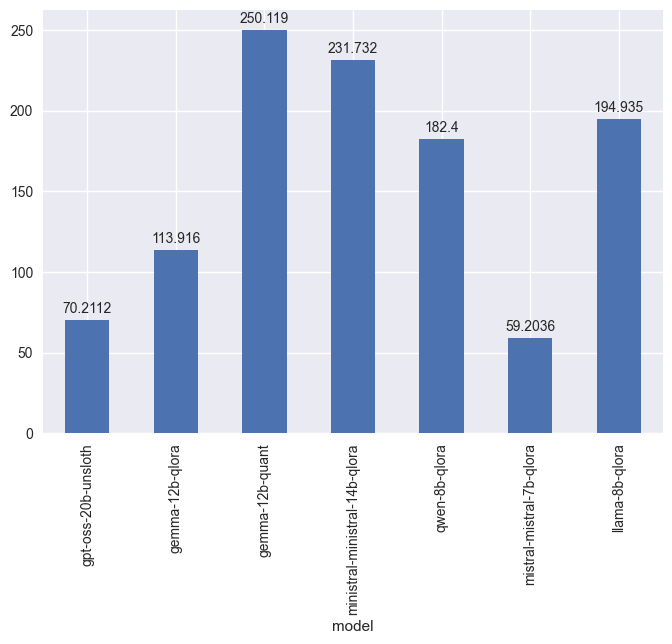

In [56]:
ax = df_qlora[['model', 'duration_m']].plot(kind='bar', x='model', y='duration_m', legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

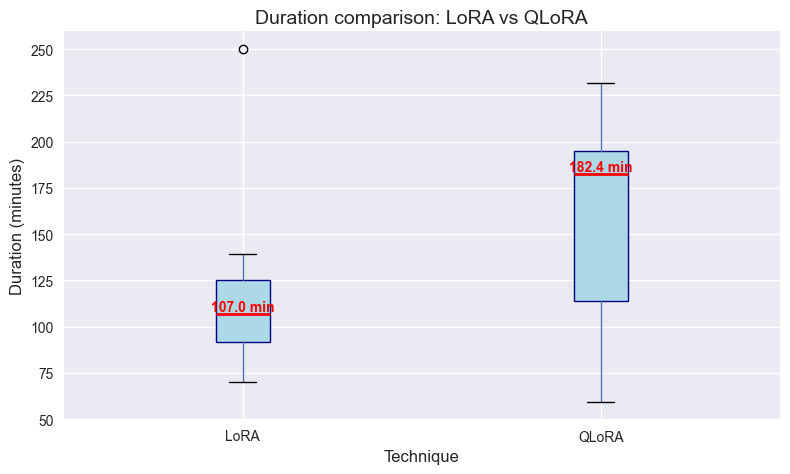

In [61]:
# Classify each experiment as LoRA or QLoRA based on model name
df_compare = df_emissions.copy()
df_compare['technique'] = df_compare['model'].apply(
    lambda m: 'QLoRA' if 'qlora' in m else 'LoRA'
)
df_compare['duration_m'] = df_compare['duration'] / 60

fig, ax = plt.subplots(figsize=(8, 5))
df_compare.boxplot(column='duration_m', by='technique', ax=ax,
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2))

for i, technique in enumerate(df_compare['technique'].unique()):
    subset = df_compare[df_compare['technique'] == technique]['duration_m']
    ax.text(i + 1, subset.median(), f'{subset.median():.1f} min',
            ha='center', va='bottom', fontweight='bold', fontsize=10, color='red')

ax.set_title('Duration comparison: LoRA vs QLoRA', fontsize=14)
ax.set_xlabel('Technique', fontsize=12)
ax.set_ylabel('Duration (minutes)', fontsize=12)
fig.suptitle('')
plt.tight_layout()
plt.show()


In [13]:
eight_bit_quant = ['ministral-ministral-14b-qlora', 'qwen-8b-qlora', 'llama-8b-qlora', 'gemma-12b-quant']

nf_four_quant = ['mistral-mistral-7b-qlora', 'gpt-oss-20b-unsloth', 'gemma-12b-qlora']

df_eight_bit_quant = df_emissions[df_emissions['model'].isin(eight_bit_quant)]
df_nf_four_quant = df_emissions[df_emissions['model'].isin(nf_four_quant)]

In [14]:
df_eight_bit_quant.describe()

,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,gpu_count,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,2.000000,2.000000,4.0
mean,12887.787252,54.039833,167.801689,10.005803,0.217566,0.602158,0.035208,0.854932,21.000000,1.0,191.650618,6.553795,46.908944,7.727447,14.836908,351.063590,0.517424,0.679167,0.585759,10.5
std,1890.558688,75.080542,12.851811,0.003813,0.312869,0.124958,0.005303,0.420148,10.392305,0.0,28.414655,3.347783,8.538124,0.904997,2.892118,60.583343,0.015711,0.008254,0.013269,3.0
min,10944.011386,4.984529,155.148890,10.000916,0.015016,0.485828,0.029903,0.530747,12.000000,1.0,167.042805,3.644985,39.540323,6.712648,11.238811,264.993742,0.506315,0.673331,0.576377,8.0
25%,11508.062940,5.121660,159.099453,10.004235,0.016172,0.498250,0.031185,0.545607,12.000000,1.0,167.042805,3.659726,40.216606,7.094645,13.530202,336.091869,0.511870,0.676249,0.581068,8.0
50%,12799.992191,23.833685,165.954178,10.006101,0.090084,0.605282,0.034955,0.730321,21.000000,1.0,191.650618,6.530510,45.301674,7.809873,14.960585,366.578174,0.517424,0.679167,0.585759,10.0
75%,14179.716503,72.751858,174.656413,10.007668,0.291478,0.709190,0.038978,1.039645,30.000000,1.0,216.258430,9.424579,51.994012,8.442675,16.267291,381.549894,0.522979,0.682086,0.590451,12.5
max,15007.153242,163.507432,184.149510,10.010094,0.675080,0.712241,0.041017,1.428338,30.000000,1.0,216.258430,9.509175,57.492105,8.577392,18.187650,406.104269,0.528534,0.685004,0.595142,14.0


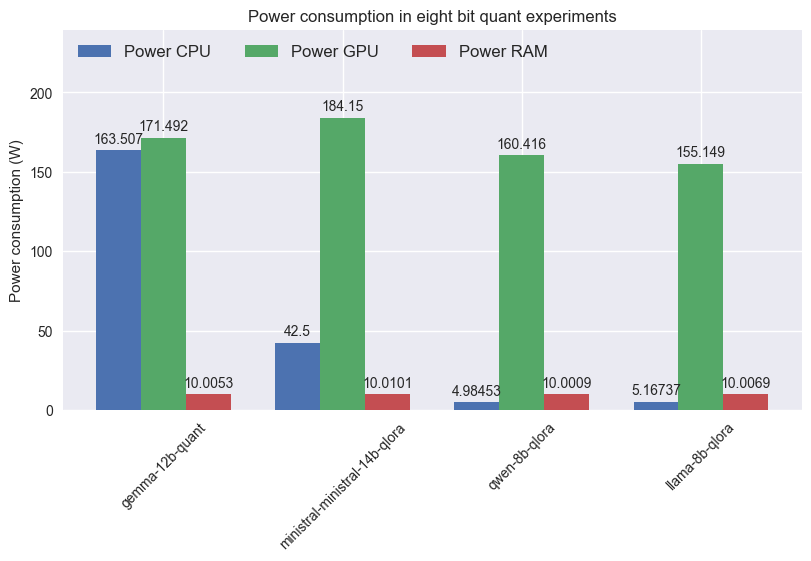

In [32]:
plot_vars_analysis(df_eight_bit_quant, 'power', 0.25, 0, 0, '../../TT2-pre/eight_bit_quant_power_consumption.png', 'Power consumption in eight bit quant experiments', 'Power consumption (W)')

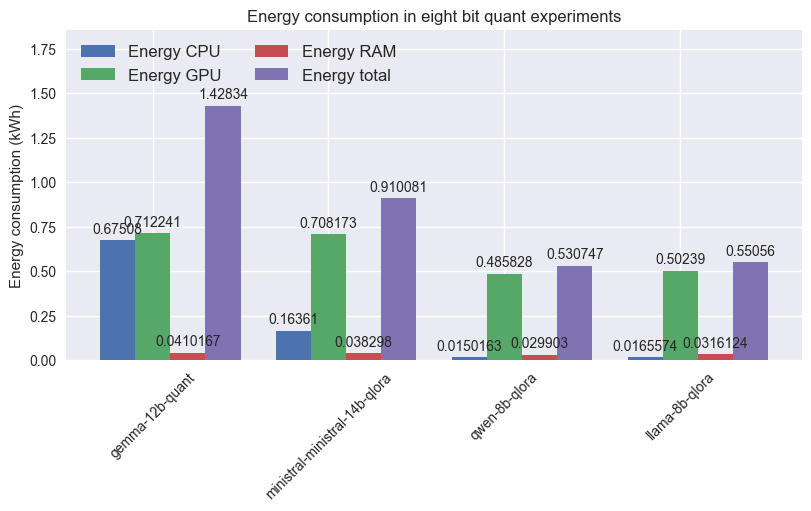

In [33]:
plot_vars_analysis(df_eight_bit_quant, 'energy', 0.20, 0, 0, '../../TT2-pre/eight_bit_quant_energy_consumption.png', 'Energy consumption in eight bit quant experiments', 'Energy consumption (kWh)')

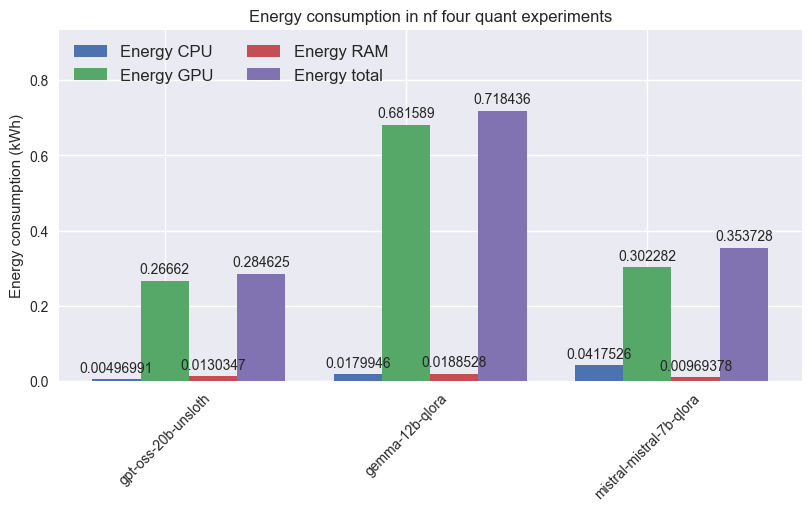

In [34]:
plot_vars_analysis(df_nf_four_quant, 'energy', 0.20, 0, 0, '../../TT2-pre/nf_four_quant_energy_consumption.png', 'Energy consumption in nf four quant experiments', 'Energy consumption (kWh)')

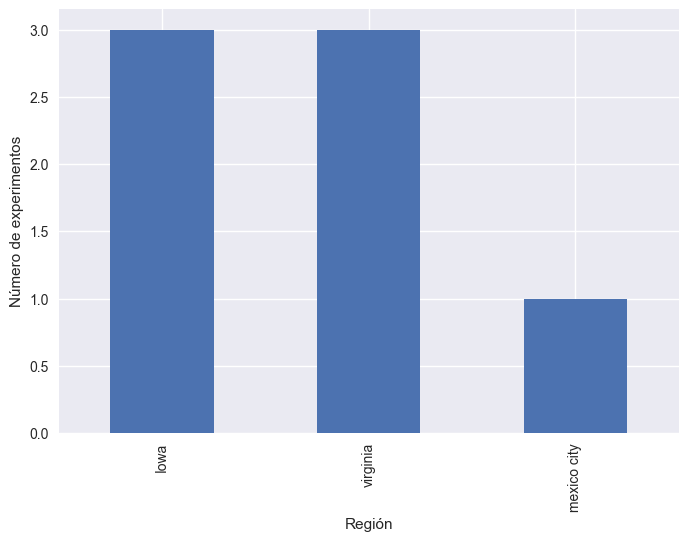

In [46]:
df_qlora['region'].value_counts().plot(kind='bar', xlabel='Región', ylabel='Número de experimentos')
plt.show()

In [47]:
df_qlora[['model', 'region']]

,model,region
0,gpt-oss-20b-unsloth,Iowa
1,gemma-12b-qlora,mexico city
2,gemma-12b-quant,virginia
3,ministral-ministral-14b-qlora,virginia
8,qwen-8b-qlora,Iowa
9,mistral-mistral-7b-qlora,virginia
11,llama-8b-qlora,Iowa


In [48]:
df_qlora[['model', 'sci_score']]

,model,sci_score
0,gpt-oss-20b-unsloth,189.509124
1,gemma-12b-qlora,356.661393
2,gemma-12b-quant,406.104269
3,ministral-ministral-14b-qlora,264.993742
8,qwen-8b-qlora,359.791245
9,mistral-mistral-7b-qlora,99.860064
11,llama-8b-qlora,373.365102


## LoRA

In [57]:
lora_models = ['ministral-ministral-14b-lora', 'qwen-qwen-3-14-fa-lora', 'qwen-8b-lora', 'qwen-qwen-3-14-sdpa-lora', 'llama-8b-lora']
df_lora = df_emissions[df_emissions['model'].isin(lora_models)]
df_lora.head()
df_lora.describe()

,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,gpu_count,...,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size,duration_m
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,...,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,5.000000,5.000000
mean,6492.699732,60.197608,179.170214,10.001278,0.093460,0.315932,0.017806,0.427198,26.400000,1.0,...,4.886679,46.133640,7.441315,15.200062,155.301907,0.760818,0.768971,0.762902,11.600000,108.211662
std,1222.302636,62.849317,36.792931,0.001377,0.082002,0.056812,0.003330,0.065811,8.049845,0.0,...,2.605988,7.646850,0.940742,0.415602,41.384787,NaN,NaN,NaN,3.286335,20.371711
min,4983.096947,4.734551,125.439936,10.000000,0.010883,0.238797,0.013609,0.323540,12.000000,1.0,...,3.672827,34.375015,6.836417,14.772854,117.214505,0.760818,0.768971,0.762902,8.000000,83.051616
25%,6030.396710,42.500000,173.174099,10.000000,0.070913,0.289858,0.016593,0.400998,30.000000,1.0,...,3.673604,44.188399,6.854688,14.794393,134.780088,0.760818,0.768971,0.762902,8.000000,100.506612
50%,6420.491519,42.500000,173.415093,10.001501,0.075534,0.307812,0.017651,0.462121,30.000000,1.0,...,3.707618,46.647695,7.199518,15.206671,137.159203,0.760818,0.768971,0.762902,14.000000,107.008192
75%,6681.373519,42.500000,199.362123,10.001563,0.078572,0.368576,0.018380,0.465527,30.000000,1.0,...,3.832407,51.212267,7.224093,15.578387,164.485228,0.760818,0.768971,0.762902,14.000000,111.356225
max,8348.139964,168.753491,224.459818,10.003324,0.231399,0.374615,0.022799,0.483806,30.000000,1.0,...,9.546940,54.244824,9.091860,15.648005,222.870510,0.760818,0.768971,0.762902,14.000000,139.135666


In [62]:
df_lora[['model', 'region']]

,model,region
4,ministral-ministral-14b-lora,virginia
5,qwen-qwen-3-14-fa-lora,virginia
6,qwen-8b-lora,Iowa
7,qwen-qwen-3-14-sdpa-lora,arizona
10,llama-8b-lora,virginia


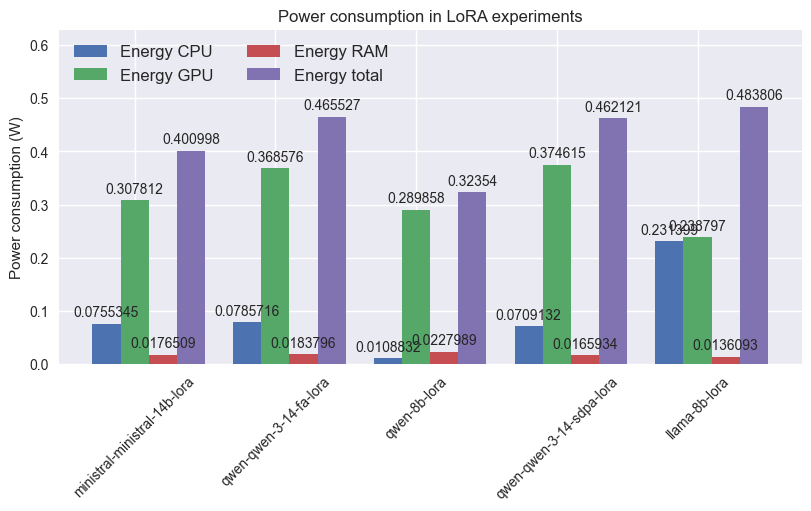

In [37]:
plot_vars_analysis(df_lora, 'energy', 0.20, 0, 0, '../../TT2-pre/lora/lora_power_consumption.png', 'Power consumption in LoRA experiments', 'Power consumption (W)')

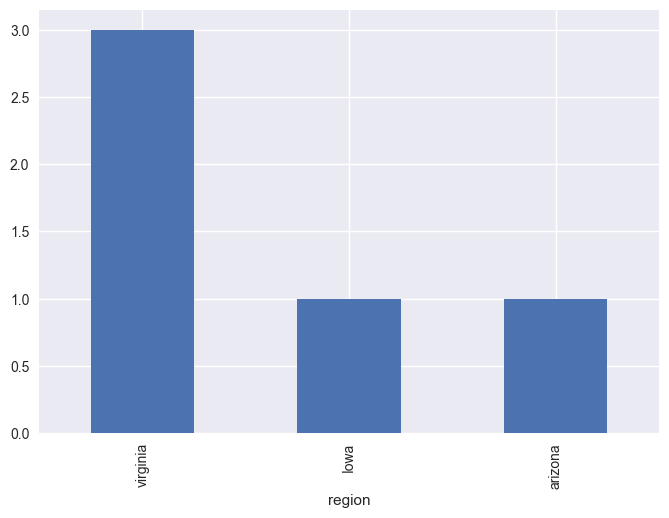

In [41]:
#plot regions by model
df_lora['region'].value_counts()
df_lora['region'].value_counts().plot(kind='bar')
plt.show()

### Analysis for Gemma experiments

In [9]:
df_gemma = df_emissions[df_emissions['project_name'].str.contains('gemma')]
df_gemma.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,cpu_model,gpu_count,gpu_model,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score
1,bio-gemma-3-12b-qlora,gemma-12b-qlora,6834.935725,9.517877,359.407776,10.002933,0.017995,0.681589,0.018853,0.718436,128,AMD EPYC 9374F 32-Core Processor,2,2 x AMD Instinct MI210,376.934826,10.298856,70.963992,9.478131,35.717012,345.619104
2,bio-gemma-3-12b-quant,gemma-12b-quant,15007.153242,163.507432,171.492048,10.005341,0.675080,0.712241,0.041017,1.428338,30,AMD EPYC 7J13 64-Core Processor,1,1 x NVIDIA A100-SXM4-40GB,216.258430,3.664639,50.161314,8.397770,18.187650,415.727025


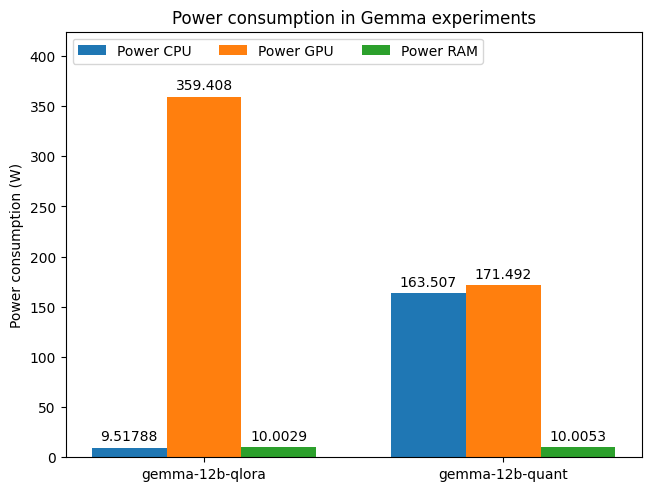

In [59]:
plot_vars_analysis(df_gemma, 'power', 0.25, 0, 0, '../../TT2-pre/gemma/gemma_power_consumption.png', 'Power consumption in Gemma experiments', 'Power consumption (W)')

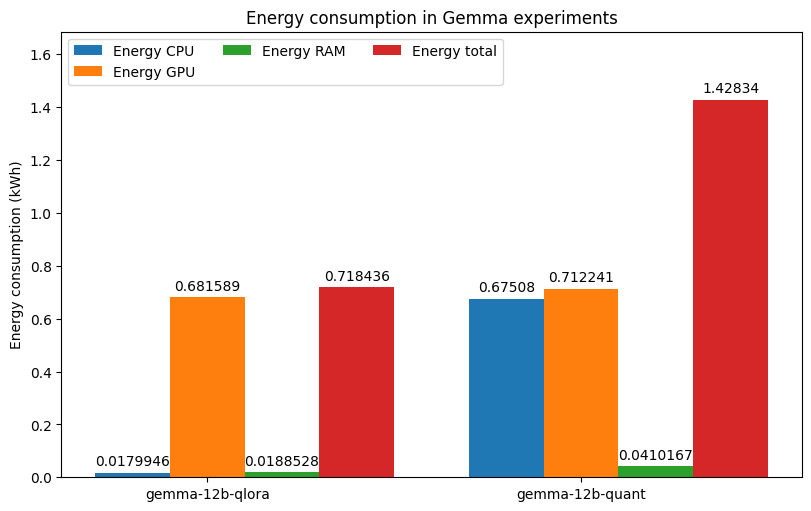

In [60]:
plot_vars_analysis(df_gemma, 'energy', 0.20, 0, 0, '../../TT2-pre/gemma/gemma_energy_consumption.png', 'Energy consumption in Gemma experiments', 'Energy consumption (kWh)')

In [70]:
plot_sci_score(df_gemma, 0.3, '../../TT2-pre/gemma/sci_gemma.png', 'SCI in Gemma experiments', 'SCI (gCO2eq/R)', 'gemma-12b-full', 7510*3)

NameError: name 'df_gemma' is not defined

In [73]:
df_emissions['cpu_model']

0       Intel(R) Xeon(R) CPU @ 2.20GHz
1     AMD EPYC 9374F 32-Core Processor
2      AMD EPYC 7J13 64-Core Processor
3      AMD EPYC 7J13 64-Core Processor
4      AMD EPYC 7J13 64-Core Processor
5      AMD EPYC 7J13 64-Core Processor
6       Intel(R) Xeon(R) CPU @ 2.20GHz
7      AMD EPYC 7J13 64-Core Processor
8       Intel(R) Xeon(R) CPU @ 2.20GHz
9      AMD EPYC 7J13 64-Core Processor
10     AMD EPYC 7J13 64-Core Processor
11      Intel(R) Xeon(R) CPU @ 2.20GHz
Name: cpu_model, dtype: str

In [75]:
df_intel = df_emissions[df_emissions['cpu_model'].str.contains('Intel')]
df_intel[['model', 'cpu_model']]

,model,cpu_model
0,gpt-oss-20b-unsloth,Intel(R) Xeon(R) CPU @ 2.20GHz
6,qwen-8b-lora,Intel(R) Xeon(R) CPU @ 2.20GHz
8,qwen-8b-qlora,Intel(R) Xeon(R) CPU @ 2.20GHz
11,llama-8b-qlora,Intel(R) Xeon(R) CPU @ 2.20GHz


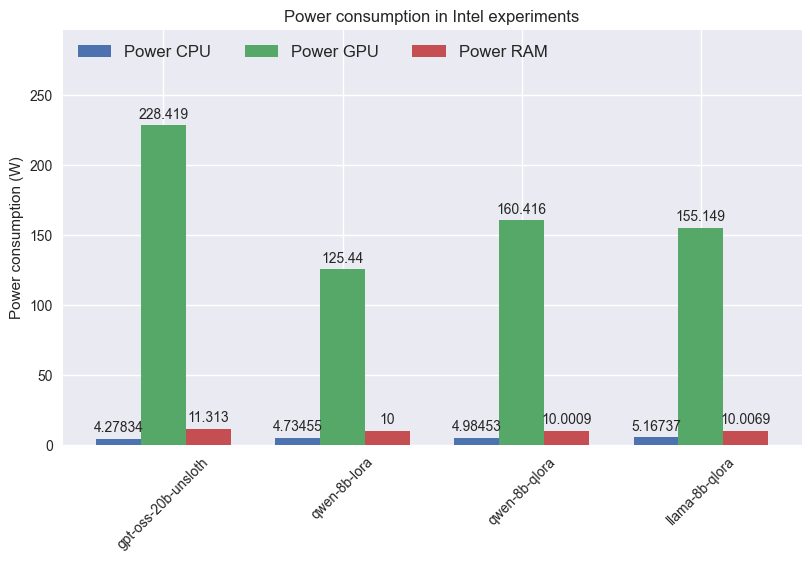

In [76]:
plot_vars_analysis(df_intel, 'power', 0.25, 0, 0, '../../TT2-pre/intel_power_consumption.png', 'Power consumption in Intel experiments', 'Power consumption (W)')

### Analysis for Llama experiments

In [11]:
df_llama = df_emissions[df_emissions['project_name'].str.contains('llama')]
df_llama.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,cpu_model,gpu_count,gpu_model,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score
10,bio-llama-3-8b-lora,llama-8b-lora,4983.096947,168.753491,173.174099,10.00000,0.231399,0.238797,0.013609,0.483806,30,AMD EPYC 7J13 64-Core Processor,1,1 x NVIDIA A100-SXM4-40GB,216.258427,3.707618,54.244824,7.199518,15.578387,140.59144
11,bio-llama-3-8b-qlora,llama-8b-qlora,11696.080124,5.167371,155.148890,10.00686,0.016557,0.502390,0.031612,0.550560,12,Intel(R) Xeon(R) CPU @ 2.20GHz,1,1 x NVIDIA A100-SXM4-80GB,167.042805,9.509175,40.442034,6.712648,11.238811,370.28517


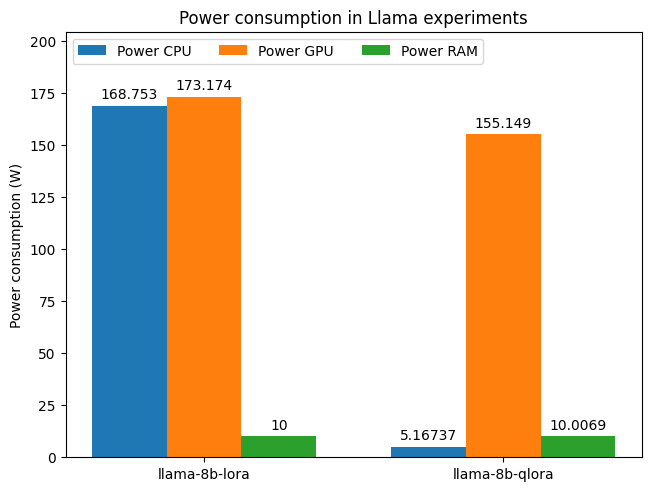

In [46]:
plot_vars_analysis(df_llama, 'power', 0.25, 0, 0, '../../TT2-pre/llama/llama_power_consumption.png', 'Power consumption in Llama experiments', 'Power consumption (W)')

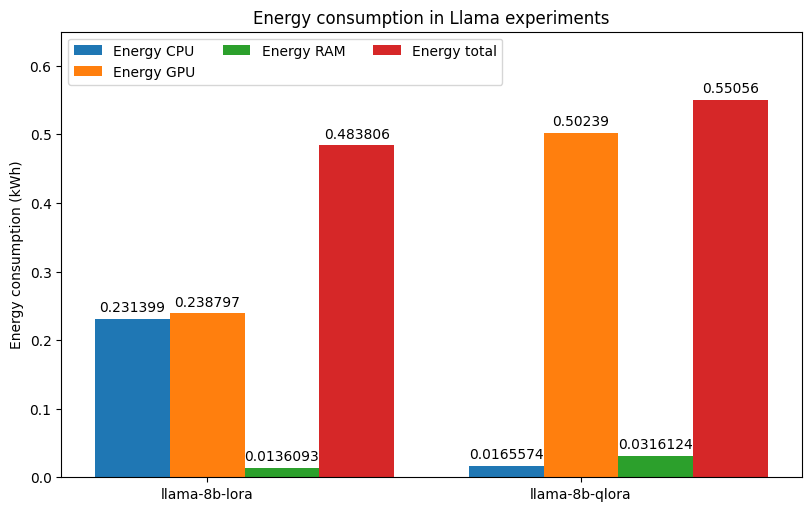

In [48]:
plot_vars_analysis(df_llama, 'energy', 0.20, 0, 0, '../../TT2-pre/llama/llama_energy_consumption.png', 'Energy consumption in Llama experiments', 'Energy consumption (kWh)')

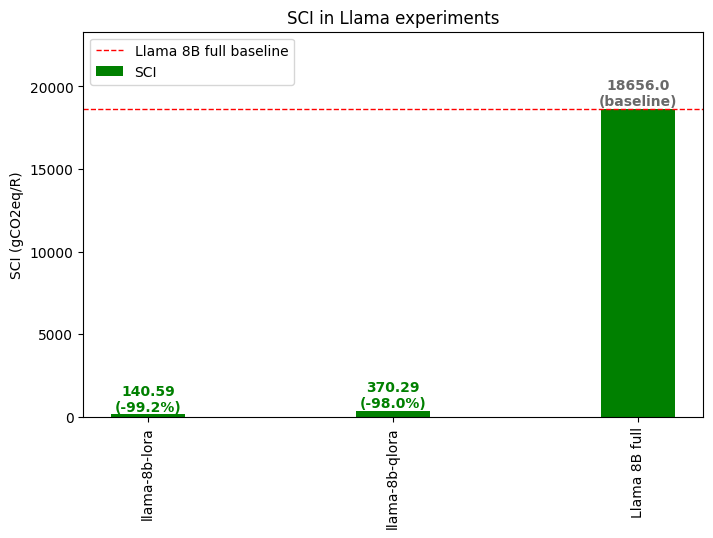

In [12]:
plot_sci_score(df_llama, 0.3, '../../TT2-pre/llama/sci_llama.png', 'SCI in Llama experiments', 'SCI (gCO2eq/R)', 'Llama 8B full', 4240*4.4)

### Mistral analysis
#### 7B

In [13]:
df_mistral = df_emissions[df_emissions['project_name'].str.contains('mistral')]
df_mistral.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,cpu_model,gpu_count,gpu_model,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score
9,bio-mistral-7b,mistral-mistral-7b-qlora,3552.214359,42.5,307.712386,10.019729,0.041753,0.302282,0.009694,0.353728,30,AMD EPYC 7J13 64-Core Processor,1,1 x NVIDIA A100-SXM4-40GB,216.258427,3.771961,87.496756,5.045811,10.860997,102.588344


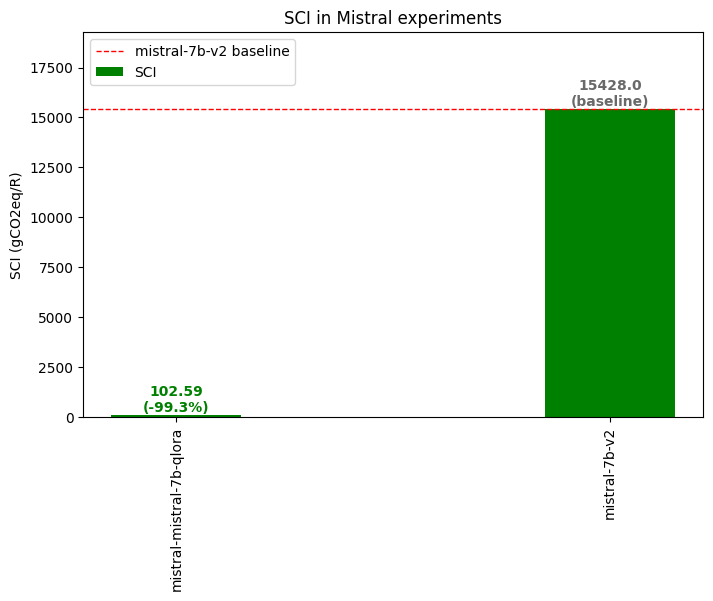

In [14]:
plot_sci_score(df_mistral, 0.3, '../../TT2-pre/mistral/sci_mistral.png', 'SCI in Mistral experiments', 'SCI (gCO2eq/R)', 'mistral-7b-v2', 4060*3.8)

#### Ministral 3 14B

In [63]:
df_ministral = df_emissions[df_emissions['project_name'].str.contains('ministral')]
df_ministral.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,...,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean,size,duration_minutes
3,bio-ministral-3-14b-qlora,ministral-ministral-14b-qlora,13903.904257,42.5,184.149510,10.010094,0.163610,0.708173,0.038298,0.910081,...,3.644985,57.492105,7.221977,15.627171,264.993742,NaN,NaN,NaN,14,231.731738
4,bio-ministral-3-14b-lora,ministral-ministral-14b-lora,6420.491519,42.5,173.415093,10.001563,0.075534,0.307812,0.017651,0.400998,...,3.672827,44.188399,7.224093,15.648005,117.214505,NaN,NaN,NaN,14,107.008192


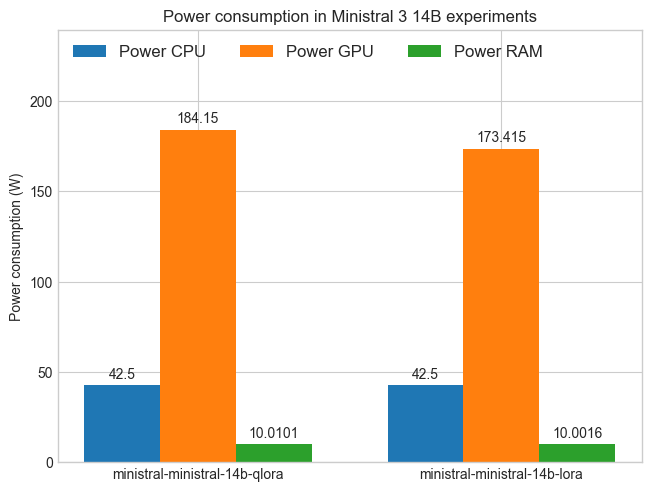

In [79]:
plot_vars_analysis(df_ministral, 'power', 0.25, 0, 0, '../../TT2-pre/ministral/ministral_power_consumption.png', 'Power consumption in Ministral 3 14B experiments', 'Power consumption (W)')

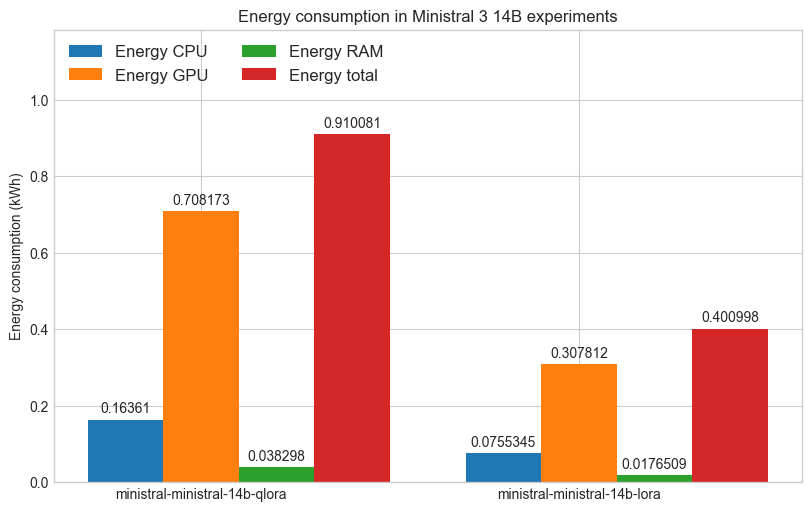

In [78]:
plot_vars_analysis(df_ministral, 'energy', 0.20, 0, 0, '../../TT2-pre/ministral/ministral_energy_consumption.png', 'Energy consumption in Ministral 3 14B experiments', 'Energy consumption (kWh)')

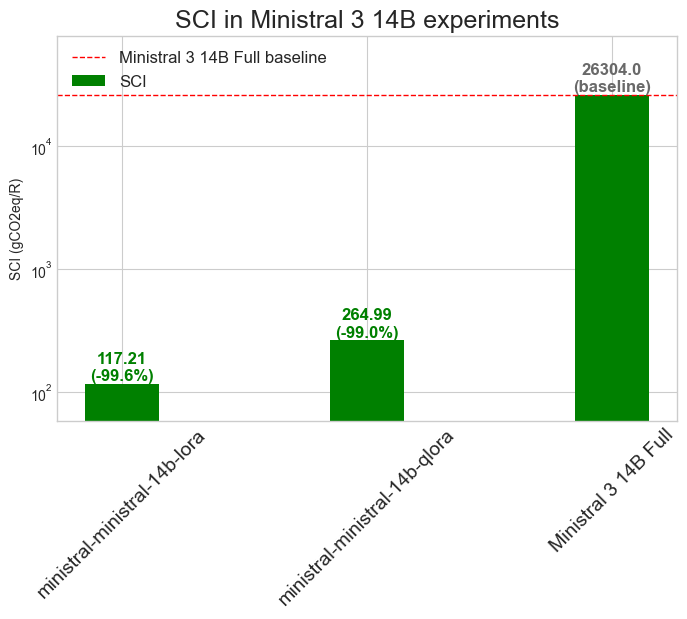

In [72]:
plot_sci_score(df_ministral, 0.3, '../../TT2-pre/ministral/sci_ministral.png', 'SCI in Ministral 3 14B experiments', 'SCI (gCO2eq/R)', 'Ministral 3 14B Full', 8220*3.2)

### Qwen analysis
#### 8B

In [17]:
df_qwen = df_emissions[df_emissions['project_name'].str.contains('qwen')]
df_qwen_8 = df_qwen[df_qwen['model'].str.contains('8b')]
df_qwen_8.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,cpu_model,gpu_count,gpu_model,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score
6,bio-qwen-3-8b-lora,qwen-8b-lora,8348.139964,4.734551,125.439936,10.000000,0.010883,0.289858,0.022799,0.323540,12,Intel(R) Xeon(R) CPU @ 2.20GHz,1,1 x NVIDIA A100-SXM4-80GB,167.042809,9.54694,34.375015,9.091860,15.206671,220.142756
8,bio-qwen-3-8b-qlora,qwen-8b-qlora,10944.011386,4.984529,160.416308,10.000916,0.015016,0.485828,0.029903,0.530747,12,Intel(R) Xeon(R) CPU @ 2.20GHz,1,1 x NVIDIA A100-SXM4-80GB,167.042805,9.39638,39.540323,8.577392,14.293998,356.388807


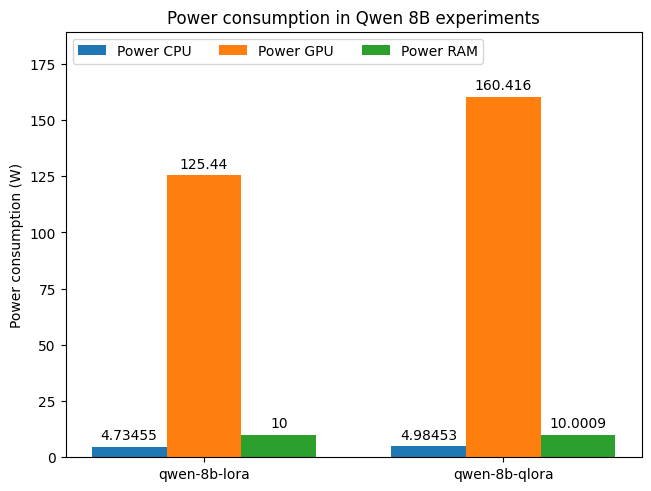

In [64]:
plot_vars_analysis(df_qwen_8, 'power', 0.25, 0, 0, '../../TT2-pre/qwen/qwen_8b_power_consumption.png', 'Power consumption in Qwen 8B experiments', 'Power consumption (W)')

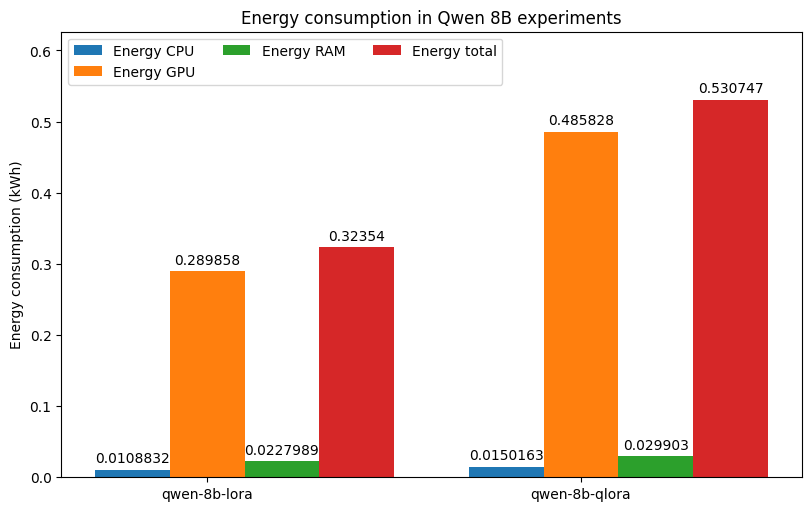

In [18]:
plot_vars_analysis(df_qwen_8, 'energy', 0.20, 0, 0, '../../TT2-pre/qwen/qwen_8b_energy_consumption.png', 'Energy consumption in Qwen 8B experiments', 'Energy consumption (kWh)')

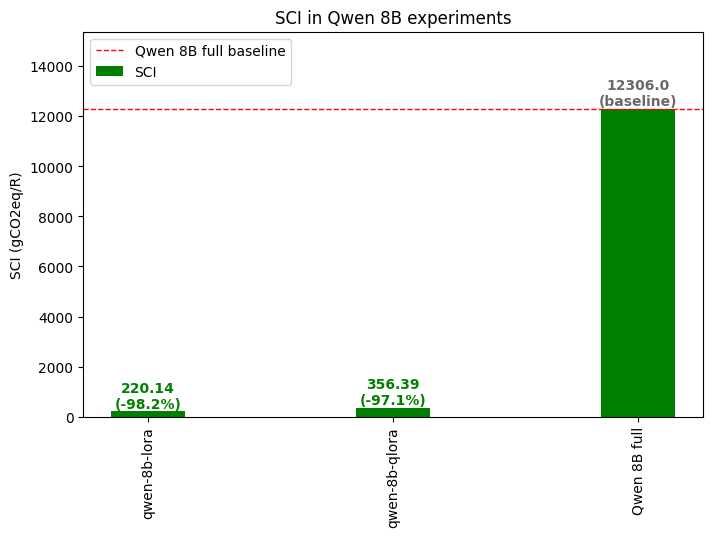

In [19]:
plot_sci_score(df_qwen_8, 0.3, '../../TT2-pre/qwen/sci_qwen_8b.png', 'SCI in Qwen 8B experiments', 'SCI (gCO2eq/R)', 'Qwen 8B full', 5860*2.1)

#### 14 B

In [20]:
df_qwen_14 = df_qwen[df_qwen['model'].str.contains('14')]
df_qwen_14.head()

,project_name,model,duration,cpu_power,gpu_power,ram_power,cpu_energy,gpu_energy,ram_energy,energy_consumed,cpu_count,cpu_model,gpu_count,gpu_model,ram_total_size,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,sci_score
5,bio-qwen-3-14b-fa-lora,qwen-qwen-3-14-fa-lora,6681.373519,42.5,199.362123,10.001501,0.078572,0.368576,0.018380,0.465527,30,AMD EPYC 7J13 64-Core Processor,1,1 x NVIDIA A100-SXM4-40GB,216.258427,3.832407,46.647695,6.836417,14.794393,139.487990
7,bio-qwen-3-14b-sdpa-lora,qwen-qwen-3-14-sdpa-lora,6030.396710,42.5,224.459818,10.003324,0.070913,0.374615,0.016593,0.462121,30,AMD EPYC 7J13 64-Core Processor,1,1 x NVIDIA A100-SXM4-40GB,216.258419,3.673604,51.212267,6.854688,14.772854,168.734431


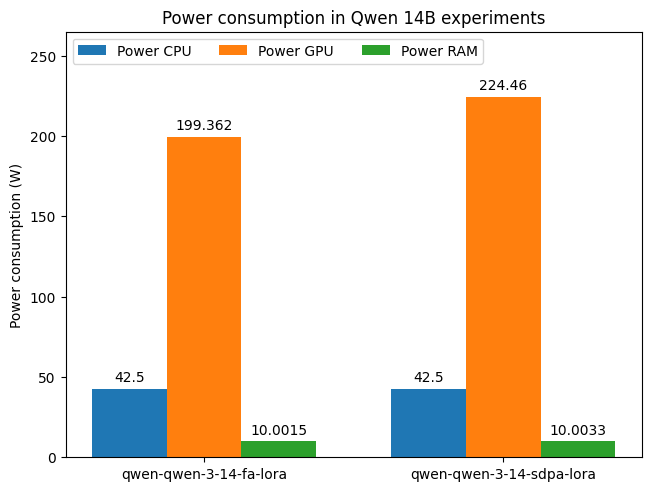

In [69]:
plot_vars_analysis(df_qwen_14, 'power', 0.25, 0, 0, '../../TT2-pre/qwen/qwen_14b_power_consumption.png', 'Power consumption in Qwen 14B experiments', 'Power consumption (W)')

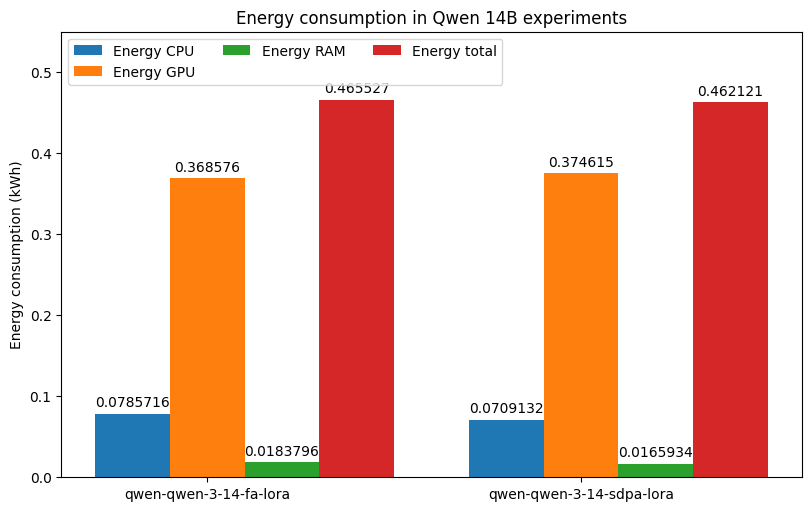

In [70]:
plot_vars_analysis(df_qwen_14, 'energy', 0.20, 0, 0, '../../TT2-pre/qwen/qwen_14b_energy_consumption.png', 'Energy consumption in Qwen 14B experiments', 'Energy consumption (kWh)')

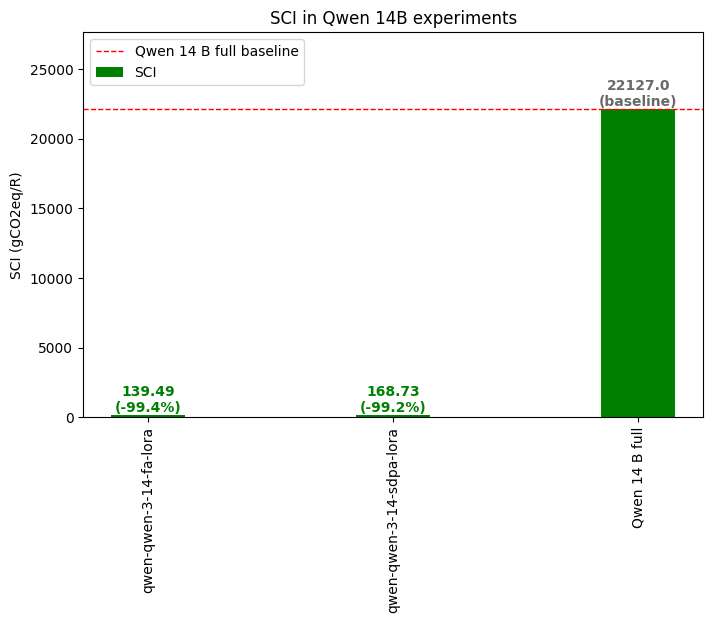

In [21]:
plot_sci_score(df_qwen_14, 0.3, '../../TT2-pre/qwen/sci_qwen_14b.png', 'SCI in Qwen 14B experiments', 'SCI (gCO2eq/R)', 'Qwen 14 B full', 7630*2.9)

### gpt-oss analysis

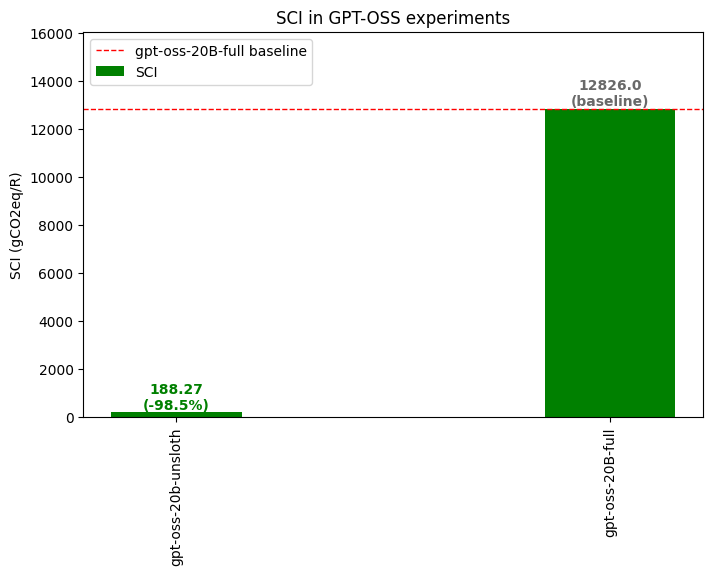

In [22]:
df_gpt_oss = df_emissions[df_emissions['project_name'].str.contains('gpt-oss')]
plot_sci_score(df_gpt_oss, 0.3, '../../TT2-pre/gpt-oss/sci_gpt_oss.png', 'SCI in GPT-OSS experiments', 'SCI (gCO2eq/R)', 'gpt-oss-20B-full', 11660*1.1)